In [1]:
### We will try to fit 4 Optical Depth Spectra from the hfs OH lines:
# We will keep the FWHM and center velocity as two free parameters,
# Then we will let the amplitudes vary for 6 free parameters per Gaussian.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import ascii

from io import StringIO

from lmfit import Model, minimize, Parameters, report_fit, fit_report
from lmfit.models import GaussianModel

import astropy.table as Table
from astropy import units as u
import pandas as pd
import OHfunc as O

%matplotlib inline

In [3]:
# Parameters for mcmc:
emcee_kws = dict(steps=5000, burn=500, thin=20, is_weighted=False,
                 progress=True)

In [4]:
# Write out function to model:

const = np.sqrt(np.pi)/(2.0*np.sqrt(np.log(2.0)))

def gaussian(x, amp, cen, wid):
    return amp * np.exp(-(x-cen)**2 / wid)

def gauss(x, amp, cen, sigma):
    """Gaussian lineshape."""
    return amp * np.exp(-(x-cen)**2 / (2.*sigma**2))

# Have to change error to be on -baseline- region, will implement later.
def ew(x,y,rms,lower=0, upper=10):
    delta = abs(x[0]-x[1])
    print(delta)
    idx = np.where((x >= lower) & (x <= upper))
    integral = np.sum(y[idx])*delta
    error = rms*np.sqrt(len(idx[0]))*delta
    print(len(idx[0]))
    return integral, error

def rms(x,y, lower=-20, upper=0):
    idx = np.where((x >= lower) & (x <= upper))
    return np.std(y[idx])

### Calculate Excitation Temperatures per line:

def ex(ew, Noh, line=67):
    #Normalized N(OH) by:
    Noh = Noh/1e14
    # Given a measured ew and Tc, and a Noh from SOFIA 2.5Thz, calculate the excitation temp
     # The equation to invert is (Neufeld 2002):
    # W_v = 0.45 *k [N(OH)/e14]/Tex (Here we assume Tc > 1000K)
    
    if line==67:
        k = 1
    elif line==65:
        k = 5/9
    elif line==12:
        k = 1/9
    elif line==20:
        k = 1/9
    else:
        print("Specify an OH line with an integer: 67, 65, 12 or 20 for 1667, 1665, 1612, 1720 MHz")
        
    return (0.45 * k * Noh)/ew

In [5]:
# Code to perform Gaussian Fitting:
# Note to self: I have cleaned this up a bit but each function should generally have a docstring.
# To Do: 
# Write doc strings for each function, clarify inputs and outputs.


In [6]:
def gauss_dataset_VLA(params, n, i, x):
    """Calculate Gaussian lineshape from parameters for chosen data set."""
    if i == 0:
        amp = params[f'amp1667_{i+1}_{n}']
        cen = params[f'cen1667_{i+1}_{n}']
        sig = params[f'sig1667_{i+1}_{n}']
    
    # For i == 1, we label this the 1665 MHz line and call those parameters.
    elif i == 1:
        amp = params[f'amp1665_{i+1}_{n}']
        cen = params[f'cen1665_{i+1}_{n}']
        sig = params[f'sig1665_{i+1}_{n}']
    
    # For i == 2, we label this the 1612 MHz line and call those parameters.
    elif i == 2:
        amp = params[f'amp1612_{i+1}_{n}']
        cen = params[f'cen1612_{i+1}_{n}']
        sig = params[f'sig1612_{i+1}_{n}']
            
    # For i == 3, we label this the 1720 MHz line and call those parameters.
    elif i == 3:
        amp = params[f'amp1720_{i+1}_{n}']
        cen = params[f'cen1720_{i+1}_{n}']
        sig = params[f'sig1720_{i+1}_{n}']
     
    return gauss(x, amp=amp, cen=cen, sigma=sig)

def gauss_dataset_sof(params, n, line, x):
    """Calculate Gaussian lineshape from parameters for chosen data set."""
    if line == "316":
        amp = params[f'amp316_{n}']
        cen = params[f'cen316_{n}']
        sig = params[f'sig316_{n}']
    
    # For i == 1, we label this the 1665 MHz line and call those parameters.
    elif line == "298":
        amp = params[f'amp298_{n}']
        cen = params[f'cen298_{n}']
        sig = params[f'sig298_{n}']
    
    # For i == 2, we label this the 1612 MHz line and call those parameters.
    elif line == "353":
        amp = params[f'amp353_{n}']
        cen = params[f'cen353_{n}']
        sig = params[f'sig353_{n}']
     
    return gauss(x, amp=amp, cen=cen, sigma=sig)

def gauss_dataset_n(params, n, i, x):
    """Calculate Gaussian lineshape from parameters for data set."""
    # Model array:
    model = []
    
    # For i == 0, we label this the 1667 MHz line and call those parameters.
    if i == 0:
        for q in range(n):
            amp = params[f'amp1667_{i+1}_{q}']
            cent = params[f'cen1667_{i+1}_{q}']
            sig = params[f'sig1667_{i+1}_{q}']
            model.append(gauss(x=x, amp=amp, cen=cent, sigma=sig))
    
    # For i == 1, we label this the 1665 MHz line and call those parameters.
    elif i == 1:
        for q in range(n):
            amp = params[f'amp1665_{i+1}_{q}']
            cent = params[f'cen1665_{i+1}_{q}']
            sig = params[f'sig1665_{i+1}_{q}']
            model.append(gauss(x=x, amp=amp, cen=cent, sigma=sig))
    
    # For i == 2, we label this the 1612 MHz line and call those parameters.
    elif i == 2:
        for q in range(n):
            amp = params[f'amp1612_{i+1}_{q}']
            cent = params[f'cen1612_{i+1}_{q}']
            sig = params[f'sig1612_{i+1}_{q}']
            model.append(gauss(x=x, amp=amp, cen=cent, sigma=sig))
            
    # For i == 3, we label this the 1720 MHz line and call those parameters.
    elif i == 3:
        for q in range(n):
            amp = params[f'amp1720_{i+1}_{q}']
            cent = params[f'cen1720_{i+1}_{q}']
            sig = params[f'sig1720_{i+1}_{q}']
            model.append(gauss(x=x, amp=amp, cen=cent, sigma=sig))
    
    gsave = 0.0*model[0]
    
    for mode in model:
        gsave += mode
     
    return gsave


def gauss_dataset_sof_n(params, n, x):
    """Calculate Gaussian lineshape from parameters for data set."""
    # Keys to Sofia Guassians:
    keys = [5,6,7]
    # Model array:
    model = []

    for num in keys:
        for q in range(n):
            if num == 5:
                amp = params[f'amp316_{q}']
                cent = params[f'cen316_{q}']
                sig = params[f'sig316_{q}']
                model.append(gauss(x=x, amp=amp, cen=cent, sigma=sig))
            if num == 6:
                amp = params[f'amp298_{q}']
                cent = params[f'cen298_{q}']
                sig = params[f'sig298_{q}']
                model.append(gauss(x=x, amp=amp, cen=cent, sigma=sig))
            if num == 7:
                amp = params[f'amp353_{q}']
                cent = params[f'cen353_{q}']
                sig = params[f'sig353_{q}']
                model.append(gauss(x=x, amp=amp, cen=cent, sigma=sig))
    
    gsave = 0.0*model[0]
    
    for mode in model:
        gsave += mode
     
    return gsave

def objective_sof_n(params, n, velSof, dataSof):
    """Calculate total residual for fits of Gaussians to several data sets.
    This taks 2 data arrays because the dataSof is a different velocity resolution.
    
    n = number of components
    params = parameters of each gaussian (7 gaussians per component)
    velSof = velocity axis
    dataSof = y axis"""
    
    residSof = 0.0*dataSof[:]
    
    # make residual for sofia data set:
    residSof[0,:] = dataSof[0,:] - gauss_dataset_sof_n(params, n, velSof)
    residSof = np.array(residSof)
    
    # now flatten this to a 1D array, as minimize() needs
    return residSof.flatten()

def objective_n(params, n, velVLA, velSof, dataVLA, dataSof, sigmaRadio, sigmaSof):
    """Calculate total residual for fits of Gaussians to several data sets.
    This taks 2 data arrays because the dataSof is a different velocity resolution.
    
    n = number of components
    params = parameters of each gaussian (7 gaussians per component)
    x = velocity axes
    sigmaRadio = 1 sigma channel error of the VLA data.
    sigmaSof = 1 sigma channel error of the SOFIA data."""
    ndata, _ = dataVLA.shape
    residVLA = 0.0*dataVLA[:]
    residSof = 0.0*dataSof[:]

    # make residual per VLA data set:
    for i in (0,1,2,3):
        residVLA[i, :] = (dataVLA[i, :] - gauss_dataset_n(params, n, i, velVLA))/sigmaRadio
        
    # make residual for sofia data set:
    residSof[0,:] = (dataSof[0,:] - gauss_dataset_sof_n(params, n, velSof))/sigmaSof
    
    # Data hacking to get all the data together:
    residVLA = residVLA.flatten()
    residVLA = residVLA.tolist()
    residSof = residSof[0]
    residSof = residSof.tolist()

    # Combine the data together:
    resid = residVLA + residSof
    resid = np.array(resid)
    resid = resid.flatten()

    # now flatten this to a 1D array, as minimize() needs
    return resid

# Add in the Gaussian for 18cm OH data:
def makeVLA(n, dataVLA, fit_params, c0=[0], a1667=[0], a1665=[0], a1612=[0], a1720=[0], s0=[0], lim=3):
    '''
    Purpose: Make the Gaussian models to fit to 4 hyperfine lamda doubling 18 cm OH lines.
    Guesses for the initial value of the free parameters can be provided: center velocity,
    amplitudes for 1667, 1665, 1612 and 1720, and velocity dispersion.
    
    Input:
    n = number of components in a spectrum to be fitted. e.g. if there are two components along the line of sight, n=2,
    this will make nx4 guassians  (one for each line).
    dataVLA = an np.array of each VLA spectrum, in units of optical depth ((Tmb-Tc)/Tc).
    fit_params = the initialized parameters from LMFIT (e.g. fit_params = Parameters()).
    c0 = A list containing the values for the initial guesses of the center of velocity for each Gaussian.
    a1667 = A list containing the values for the initial gueses of the amplitude of the 1667 line for each Gaussian.
    a1665 = A list containing the values for the initial gueses of the amplitude of the 1665 line for each Gaussian.
    a1612 = A list containing the values for the initial gueses of the amplitude of the 1612 line for each Gaussian.
    a1720 = A list containing the values for the initial gueses of the amplitude of the 1720 line for each Gaussian.
    s0 = A list contianing the values for the initial gueses of the velocity dispersion for each gaussian.
    
    Notes on bounds:
    The bounds on the parameters can be altered here with the min and max keywords, which use a +/- intial guess notation.
    For now the bounds are set to +/- 0.01 amplitude, +5 km/s of sigma, and +/- 1 km/s on centroid velocity.
    These bounds are quite tight and so the goodness of the fit depends on visual determination of intial conditions.
    
    Output:
    None, but Parameters will be updated.
    '''
    for q in range(n):
        for iy, y in enumerate(dataVLA):
            # Gaussian 1667
            if iy == 0:
                fit_params.add(f'amp1667_{iy+1}_{q}', value=a1667[q], min=a1667[q]-1, max=0)
                fit_params.add(f'cen1667_{iy+1}_{q}', value=c0[q], min = c0[q]-lim, max = c0[q]+lim)
                fit_params.add(f'sig1667_{iy+1}_{q}', value=s0[q], min=0, max=s0[q]+3)
                # Make the parameter for equivalent width:
                fit_params.add(f'W1667_{iy+1}_{q}', value=0)
                fit_params[f'W1667_{iy+1}_{q}'].expr = f'amp1667_{iy+1}_{q}*((2.355*sig1667_{iy+1}_{q})/(2*sqrt(2*log(2))))*sqrt(2*pi)'
            elif iy == 1:
                # Gaussian 1665
                fit_params.add(f'amp1665_{iy+1}_{q}', value=a1665[q], min=a1665[q]-1, max=0)
                fit_params.add(f'cen1665_{iy+1}_{q}', value=c0[q], min = c0[q]-lim, max = c0[q]+lim)
                fit_params.add(f'sig1665_{iy+1}_{q}', value=s0[q], min=0, max=s0[q]+3)
                # Make the parameter for equivalent width:
                fit_params.add(f'W1665_{iy+1}_{q}', value=0)
                fit_params[f'W1665_{iy+1}_{q}'].expr = f'amp1665_{iy+1}_{q}*((2.355*sig1665_{iy+1}_{q})/(2*sqrt(2*log(2))))*sqrt(2*pi)'
                # Set the 1665 to have the same parameters as 1667:
                fit_params[f'sig1665_{iy+1}_{q}'].expr = f'sig1667_1_{q}'
                fit_params[f'cen1665_{iy+1}_{q}'].expr = f'cen1667_1_{q}'
            elif iy == 2:
                # Gaussian 1612
                fit_params.add(f'amp1612_{iy+1}_{q}', value=a1612[q], min=a1612[q]-1, max=a1612[q]+1)
                fit_params.add(f'cen1612_{iy+1}_{q}', value=c0[q], min = c0[q]-lim, max = c0[q]+lim)
                fit_params.add(f'sig1612_{iy+1}_{q}', value=s0[q], min=0, max=s0[q]+3)
                # Make the parameter for equivalent width:
                fit_params.add(f'W1612_{iy+1}_{q}', value=0)
                fit_params[f'W1612_{iy+1}_{q}'].expr = f'amp1612_{iy+1}_{q}*((2.355*sig1612_{iy+1}_{q})/(2*sqrt(2*log(2))))*sqrt(2*pi)'
                # Set the 1612 to have the same parameters as 1667:
                fit_params[f'sig1612_{iy+1}_{q}'].expr = f'sig1667_1_{q}'
                fit_params[f'cen1612_{iy+1}_{q}'].expr = f'cen1667_1_{q}'
            elif iy == 3:
                # Gaussian 1720
                fit_params.add(f'amp1720_{iy+1}_{q}', value=a1720[q], min=a1720[q]-1, max=a1720[q]+1)
                fit_params.add(f'cen1720_{iy+1}_{q}', value=c0[q], min = c0[q]-lim, max = c0[q]+lim)
                fit_params.add(f'sig1720_{iy+1}_{q}', value=s0[q], min=0, max=s0[q]+3)
                # Make the parameter for equivalent width:
                fit_params.add(f'W1720_{iy+1}_{q}', value=0)
                fit_params[f'W1720_{iy+1}_{q}'].expr = f'amp1720_{iy+1}_{q}*((2.355*sig1720_{iy+1}_{q})/(2*sqrt(2*log(2))))*sqrt(2*pi)'
                # Set the 1720 to have the same parameters as 1667:
                fit_params[f'sig1720_{iy+1}_{q}'].expr = f'sig1667_1_{q}'
                fit_params[f'cen1720_{iy+1}_{q}'].expr = f'cen1667_1_{q}'
        
#Add in the SOFIA Hfs lines:
def makeSOFIA(n, dataSof, fit_params, c0=[0], s0=[0], aSof=[0]):
    '''
    Purpose: Make the Gaussian models to fit to 3 hyperfine lamda doubling 2.5 THz OH lines.
    Guesses for the initial value of the free parameters can be provided: amplitude for the
    strongest HFS line: 2514316
    
    In this code, the parameters labeled 316 refer to the 2514316.404 GHz line,
    the parameters labeled 298 refer to the 2514298.058 GHz line, and
    the parameters labeled 353 refer to the 2514353.187 GHz line.
    
    The 2.5 THz spectra's velocity scale is set for the strongest HFS (hyperfine structure) line at 2514316.404 GHz. 
    The 2514298.058 GHz and 2514353.187 GHz lines are offset by 2.07 km/s and –4.4 km/s, respectively. 
    HFS Weights (𝑊𝐻𝐹𝑆 ): 2514298.058 GHz: 2514316.404 GHz: 2514353.187 GHz = 0.042: 0.583: 0.375 (1: 14: 9)
    
    Input:
    n = number of components in a spectrum to be fitted. e.g. if there are two components along the line of sight, n=2,
    this will make nx3 guassians  (one for each HFS).
    dataSof = an np.array of the SOFIA spectrum, in units of optical depth ((Tmb-Tc)/Tc).
    fit_params = the initialized parameters from LMFIT (e.g. fit_params = Parameters()).
    aSof = A list containing the values for the initial gueses of the amplitude of the 1667 line for each Gaussian.
    
    Notes on bounds:
    The bounds on the parameters can be altered here with the min and max keywords, which use a +/- intial guess notation.
    For now the bounds are set to +/- 0.01 amplitude, +5 km/s of sigma, and +/- 1 km/s on centroid velocity.
    These bounds are quite tight and so the goodness of the fit depends on visual determination of intial conditions.
    
    Output:
    None, but Parameters will be updated.
    '''
    for q in range(n):
        fit_params.add(f'amp316_{q}', value=aSof[q], min=aSof[q]-1, max=0)
        fit_params.add(f'cen316_{q}', value=0)
        fit_params.add(f'sig316_{q}', value=0)
        # Make the parameter for equivalent width:
        fit_params.add(f'W316_{q}', value=0)
        fit_params[f'W316_{q}'].expr = f'amp316_{q}*((2.355*sig316_{q})/(2*sqrt(2*log(2))))*sqrt(2*pi)'

        fit_params.add(f'amp298_{q}', value=0)
        fit_params.add(f'cen298_{q}', value=0)
        fit_params.add(f'sig298_{q}', value=0)
        # Make the parameter for equivalent width:
        fit_params.add(f'W298_{q}', value=0)
        fit_params[f'W298_{q}'].expr = f'amp298_{q}*((2.355*sig298_{q})/(2*sqrt(2*log(2))))*sqrt(2*pi)'

        fit_params.add(f'amp353_{q}', value=0)
        fit_params.add(f'cen353_{q}', value=0)
        fit_params.add(f'sig353_{q}', value=0)
        # Make the parameter for equivalent width:
        fit_params.add(f'W353_{q}', value=0)
        fit_params[f'W353_{q}'].expr = f'amp353_{q}*((2.355*sig353_{q})/(2*sqrt(2*log(2))))*sqrt(2*pi)'

        # Set the hyperfine constraints.
        # First HFS Gaussian:
        fit_params[f'sig316_{q}'].expr = f'sig1667_1_{q}'
        fit_params[f'cen316_{q}'].expr = f'cen1667_1_{q}'
        # Second HFS Gaussian
        fit_params[f'amp298_{q}'].expr = f'0.071* amp316_{q}'
        fit_params[f'sig298_{q}'].expr = f'sig316_{q}'
        fit_params[f'cen298_{q}'].expr = f'cen316_{q}+2.07'
        # Third HFS Gaussian
        fit_params[f'amp353_{q}'].expr = f'0.64* amp316_{q}'
        fit_params[f'sig353_{q}'].expr = f'sig316_{q}'
        fit_params[f'cen353_{q}'].expr = f'cen316_{q}-4.4'

In [7]:
def gauss_dataset_VLA(params, n, i, x):
    """Calculate Gaussian lineshape from parameters for chosen data set."""
    if i == 0:
        amp = params[f'amp1667_{i+1}_{n}']
        cen = params[f'cen1667_{i+1}_{n}']
        sig = params[f'sig1667_{i+1}_{n}']
    
    # For i == 1, we label this the 1665 MHz line and call those parameters.
    elif i == 1:
        amp = params[f'amp1665_{i+1}_{n}']
        cen = params[f'cen1665_{i+1}_{n}']
        sig = params[f'sig1665_{i+1}_{n}']
    
    # For i == 2, we label this the 1612 MHz line and call those parameters.
    elif i == 2:
        amp = params[f'amp1612_{i+1}_{n}']
        cen = params[f'cen1612_{i+1}_{n}']
        sig = params[f'sig1612_{i+1}_{n}']
            
    # For i == 3, we label this the 1720 MHz line and call those parameters.
    elif i == 3:
        amp = params[f'amp1720_{i+1}_{n}']
        cen = params[f'cen1720_{i+1}_{n}']
        sig = params[f'sig1720_{i+1}_{n}']
     
    return gauss(x, amp=amp/(sig*2.355*1.0645), cen=cen, sigma=sig)

def gauss_dataset_sof(params, n, line, x):
    """Calculate Gaussian lineshape from parameters for chosen data set."""
    if line == "316":
        amp = params[f'amp316_{n}']
        cen = params[f'cen316_{n}']
        sig = params[f'sig316_{n}']
    
    # For i == 1, we label this the 1665 MHz line and call those parameters.
    elif line == "298":
        amp = params[f'amp298_{n}']
        cen = params[f'cen298_{n}']
        sig = params[f'sig298_{n}']
    
    # For i == 2, we label this the 1612 MHz line and call those parameters.
    elif line == "353":
        amp = params[f'amp353_{n}']
        cen = params[f'cen353_{n}']
        sig = params[f'sig353_{n}']
     
    return gauss(x, amp=amp/(sig*2.355*1.0645), cen=cen, sigma=sig)

def gauss_dataset_n(params, n, i, x):
    """Calculate Gaussian lineshape from parameters for data set."""
    # Model array:
    model = []
    
    # For i == 0, we label this the 1667 MHz line and call those parameters.
    if i == 0:
        for q in range(n):
            amp = params[f'amp1667_{i+1}_{q}']
            cent = params[f'cen1667_{i+1}_{q}']
            sig = params[f'sig1667_{i+1}_{q}']
            model.append(gauss(x=x, amp=amp/(sig*2.355*1.0645), cen=cent, sigma=sig))
    
    # For i == 1, we label this the 1665 MHz line and call those parameters.
    elif i == 1:
        for q in range(n):
            amp = params[f'amp1665_{i+1}_{q}']
            cent = params[f'cen1665_{i+1}_{q}']
            sig = params[f'sig1665_{i+1}_{q}']
            model.append(gauss(x=x, amp=amp/(sig*2.355*1.0645), cen=cent, sigma=sig))
    
    # For i == 2, we label this the 1612 MHz line and call those parameters.
    elif i == 2:
        for q in range(n):
            amp = params[f'amp1612_{i+1}_{q}']
            cent = params[f'cen1612_{i+1}_{q}']
            sig = params[f'sig1612_{i+1}_{q}']
            model.append(gauss(x=x, amp=amp/(sig*2.355*1.0645), cen=cent, sigma=sig))
            
    # For i == 3, we label this the 1720 MHz line and call those parameters.
    elif i == 3:
        for q in range(n):
            amp = params[f'amp1720_{i+1}_{q}']
            cent = params[f'cen1720_{i+1}_{q}']
            sig = params[f'sig1720_{i+1}_{q}']
            model.append(gauss(x=x, amp=amp/(sig*2.355*1.0645), cen=cent, sigma=sig))
    
    gsave = 0.0*model[0]
    
    for mode in model:
        gsave += mode
     
    return gsave


def gauss_dataset_sof_n(params, n, x):
    """Calculate Gaussian lineshape from parameters for data set."""
    # Keys to Sofia Guassians:
    keys = [5,6,7]
    # Model array:
    model = []

    for num in keys:
        for q in range(n):
            if num == 5:
                amp = params[f'amp316_{q}']
                cent = params[f'cen316_{q}']
                sig = params[f'sig316_{q}']
                model.append(gauss(x=x, amp=amp/(sig*2.355*1.0645), cen=cent, sigma=sig))
            if num == 6:
                amp = params[f'amp298_{q}']
                cent = params[f'cen298_{q}']
                sig = params[f'sig298_{q}']
                model.append(gauss(x=x, amp=amp/(sig*2.355*1.0645), cen=cent, sigma=sig))
            if num == 7:
                amp = params[f'amp353_{q}']
                cent = params[f'cen353_{q}']
                sig = params[f'sig353_{q}']
                model.append(gauss(x=x, amp=amp/(sig*2.355*1.0645), cen=cent, sigma=sig))
    
    gsave = 0.0*model[0]
    
    for mode in model:
        gsave += mode
     
    return gsave

def objective_sof_n(params, n, velSof, dataSof):
    """Calculate total residual for fits of Gaussians to several data sets.
    This taks 2 data arrays because the dataSof is a different velocity resolution.
    
    n = number of components
    params = parameters of each gaussian (7 gaussians per component)
    velSof = velocity axis
    dataSof = y axis"""
    
    residSof = 0.0*dataSof[:]
    
    # make residual for sofia data set:
    residSof[0,:] = dataSof[0,:] - gauss_dataset_sof_n(params, n, velSof)
    residSof = np.array(residSof)
    
    # now flatten this to a 1D array, as minimize() needs
    return residSof.flatten()

def objective_n(params, n, velVLA, velSof, dataVLA, dataSof, sigmaRadio, sigmaSof):
    """Calculate total residual for fits of Gaussians to several data sets.
    This taks 2 data arrays because the dataSof is a different velocity resolution.
    
    n = number of components
    params = parameters of each gaussian (7 gaussians per component)
    x = velocity axes
    sigmaRadio = 1 sigma channel error of the VLA data.
    sigmaSof = 1 sigma channel error of the SOFIA data."""
    ndata, _ = dataVLA.shape
    residVLA = 0.0*dataVLA[:]
    residSof = 0.0*dataSof[:]

    # make residual per VLA data set:
    for i in (0,1,2,3):
        residVLA[i, :] = (dataVLA[i, :] - gauss_dataset_n(params, n, i, velVLA))/sigmaRadio
        
    # make residual for sofia data set:
    residSof[0,:] = (dataSof[0,:] - gauss_dataset_sof_n(params, n, velSof))/sigmaSof
    
    # Data hacking to get all the data together:
    residVLA = residVLA.flatten()
    residVLA = residVLA.tolist()
    residSof = residSof[0]
    residSof = residSof.tolist()

    # Combine the data together:
    resid = residVLA + residSof
    resid = np.array(resid)
    resid = resid.flatten()

    # now flatten this to a 1D array, as minimize() needs
    return resid

# Add in the Gaussian for 18cm OH data:
def makeVLA(n, dataVLA, fit_params, c0=[0], a1667=[0], a1665=[0], a1612=[0], a1720=[0], s0=[0], lim=3):
    '''
    Purpose: Make the Gaussian models to fit to 4 hyperfine lamda doubling 18 cm OH lines.
    Guesses for the initial value of the free parameters can be provided: center velocity,
    amplitudes for 1667, 1665, 1612 and 1720, and velocity dispersion.
    
    Input:
    n = number of components in a spectrum to be fitted. e.g. if there are two components along the line of sight, n=2,
    this will make nx4 guassians  (one for each line).
    dataVLA = an np.array of each VLA spectrum, in units of optical depth ((Tmb-Tc)/Tc).
    fit_params = the initialized parameters from LMFIT (e.g. fit_params = Parameters()).
    c0 = A list containing the values for the initial guesses of the center of velocity for each Gaussian.
    a1667 = A list containing the values for the initial gueses of the amplitude of the 1667 line for each Gaussian.
    a1665 = A list containing the values for the initial gueses of the amplitude of the 1665 line for each Gaussian.
    a1612 = A list containing the values for the initial gueses of the amplitude of the 1612 line for each Gaussian.
    a1720 = A list containing the values for the initial gueses of the amplitude of the 1720 line for each Gaussian.
    s0 = A list contianing the values for the initial gueses of the velocity dispersion for each gaussian.
    
    Notes on bounds:
    The bounds on the parameters can be altered here with the min and max keywords, which use a +/- intial guess notation.
    For now the bounds are set to +/- 0.01 amplitude, +5 km/s of sigma, and +/- 1 km/s on centroid velocity.
    These bounds are quite tight and so the goodness of the fit depends on visual determination of intial conditions.
    
    Output:
    None, but Parameters will be updated.
    '''
    for q in range(n):
        for iy, y in enumerate(dataVLA):
            # Gaussian 1667
            if iy == 0:
                fit_params.add(f'amp1667_{iy+1}_{q}', value=a1667[q], min=a1667[q]-1, max=0)
                fit_params.add(f'cen1667_{iy+1}_{q}', value=c0[q], min = c0[q]-lim, max = c0[q]+lim)
                fit_params.add(f'sig1667_{iy+1}_{q}', value=s0[q], min=0, max=s0[q]+3)
            elif iy == 1:
                # Gaussian 1665
                fit_params.add(f'amp1665_{iy+1}_{q}', value=a1665[q], min=a1665[q]-1, max=0)
                fit_params.add(f'cen1665_{iy+1}_{q}', value=c0[q], min = c0[q]-lim, max = c0[q]+lim)
                fit_params.add(f'sig1665_{iy+1}_{q}', value=s0[q], min=0, max=s0[q]+3)
                # Set the 1665 to have the same parameters as 1667:
                fit_params[f'sig1665_{iy+1}_{q}'].expr = f'sig1667_1_{q}'
                fit_params[f'cen1665_{iy+1}_{q}'].expr = f'cen1667_1_{q}'
            elif iy == 2:
                # Gaussian 1612
                fit_params.add(f'amp1612_{iy+1}_{q}', value=a1612[q], min=a1612[q]-1, max=a1612[q]+1)
                fit_params.add(f'cen1612_{iy+1}_{q}', value=c0[q], min = c0[q]-lim, max = c0[q]+lim)
                fit_params.add(f'sig1612_{iy+1}_{q}', value=s0[q], min=0, max=s0[q]+3)
                # Set the 1612 to have the same parameters as 1667:
                fit_params[f'sig1612_{iy+1}_{q}'].expr = f'sig1667_1_{q}'
                fit_params[f'cen1612_{iy+1}_{q}'].expr = f'cen1667_1_{q}'
            elif iy == 3:
                # Gaussian 1720
                fit_params.add(f'amp1720_{iy+1}_{q}', value=a1720[q], min=a1720[q]-1, max=a1720[q]+1)
                fit_params.add(f'cen1720_{iy+1}_{q}', value=c0[q], min = c0[q]-lim, max = c0[q]+lim)
                fit_params.add(f'sig1720_{iy+1}_{q}', value=s0[q], min=0, max=s0[q]+3)
                # Set the 1720 to have the same parameters as 1667:
                fit_params[f'sig1720_{iy+1}_{q}'].expr = f'sig1667_1_{q}'
                fit_params[f'cen1720_{iy+1}_{q}'].expr = f'cen1667_1_{q}'
        
#Add in the SOFIA Hfs lines:
def makeSOFIA(n, dataSof, fit_params, c0=[0], s0=[0], aSof=[0]):
    '''
    Purpose: Make the Gaussian models to fit to 3 hyperfine lamda doubling 2.5 THz OH lines.
    Guesses for the initial value of the free parameters can be provided: amplitude for the
    strongest HFS line: 2514316
    
    In this code, the parameters labeled 316 refer to the 2514316.404 GHz line,
    the parameters labeled 298 refer to the 2514298.058 GHz line, and
    the parameters labeled 353 refer to the 2514353.187 GHz line.
    
    The 2.5 THz spectra's velocity scale is set for the strongest HFS (hyperfine structure) line at 2514316.404 GHz. 
    The 2514298.058 GHz and 2514353.187 GHz lines are offset by 2.07 km/s and –4.4 km/s, respectively. 
    HFS Weights (𝑊𝐻𝐹𝑆 ): 2514298.058 GHz: 2514316.404 GHz: 2514353.187 GHz = 0.042: 0.583: 0.375 (1: 14: 9)
    
    Input:
    n = number of components in a spectrum to be fitted. e.g. if there are two components along the line of sight, n=2,
    this will make nx3 guassians  (one for each HFS).
    dataSof = an np.array of the SOFIA spectrum, in units of optical depth ((Tmb-Tc)/Tc).
    fit_params = the initialized parameters from LMFIT (e.g. fit_params = Parameters()).
    aSof = A list containing the values for the initial gueses of the amplitude of the 1667 line for each Gaussian.
    
    Notes on bounds:
    The bounds on the parameters can be altered here with the min and max keywords, which use a +/- intial guess notation.
    For now the bounds are set to +/- 0.01 amplitude, +5 km/s of sigma, and +/- 1 km/s on centroid velocity.
    These bounds are quite tight and so the goodness of the fit depends on visual determination of intial conditions.
    
    Output:
    None, but Parameters will be updated.
    '''
    for q in range(n):
        fit_params.add(f'amp316_{q}', value=aSof[q], min=aSof[q]-1, max=0)
        fit_params.add(f'cen316_{q}', value=0)
        fit_params.add(f'sig316_{q}', value=0)

        fit_params.add(f'amp298_{q}', value=0)
        fit_params.add(f'cen298_{q}', value=0)
        fit_params.add(f'sig298_{q}', value=0)

        fit_params.add(f'amp353_{q}', value=0)
        fit_params.add(f'cen353_{q}', value=0)
        fit_params.add(f'sig353_{q}', value=0)

        # Set the hyperfine constraints.
        # First HFS Gaussian:
        fit_params[f'sig316_{q}'].expr = f'sig1667_1_{q}'
        fit_params[f'cen316_{q}'].expr = f'cen1667_1_{q}'
        # Second HFS Gaussian
        fit_params[f'amp298_{q}'].expr = f'0.071* amp316_{q}'
        fit_params[f'sig298_{q}'].expr = f'sig316_{q}'
        fit_params[f'cen298_{q}'].expr = f'cen316_{q}+2.07'
        # Third HFS Gaussian
        fit_params[f'amp353_{q}'].expr = f'0.64* amp316_{q}'
        fit_params[f'sig353_{q}'].expr = f'sig316_{q}'
        fit_params[f'cen353_{q}'].expr = f'cen316_{q}-4.4'

### Load and plot the PRISMAS Sources:
#### W51, W49N, G34.3

In [826]:
# Load OH spectra toward W51:

# Attempt to loading the SOFIA data:
#ohsof = ascii.read('ASCII_data_files/ASCII_data_files/W51E4_OH_2Pi32_velo.txt', format='csv', delimiter=' ', data_start=0, names=["Velo", "Tb"])
ohsof = ascii.read('OH_data_deltav_0p1/W51E_OH_dv0p1.txt', format='csv', delimiter=' ', data_start=0, names=["Velo", "Tb"])
w51noh = ascii.read('Column_density_distributions/Column_density_distributions/coldens_OH_W51E4.csv')

# Sofia spectrum is in Tmb
TaSof = ohsof["Tb"]
VelSof = ohsof["Velo"]

# Velocity Bounds being set:
up = -40
low = 30

igood = np.where((VelSof >= up) & (VelSof <= low))

TaSof = ohsof["Tb"][igood]
VelSof = ohsof["Velo"][igood]

# For W51 1:
oh67 = ascii.read("VLAdata/VLASpectra/W51e/HYGAL_W51_oh3_niter10000_threshold100mJybeam_highres_cube.20arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2023-12-10-23-25-43.tsv", format='tab', names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)
oh65 = ascii.read("VLAdata/VLASpectra/W51e/HYGAL_W51_oh2_niter10000_threshold100mJybeam_highres_cube.20arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2023-12-10-23-25-43.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)
oh12 = ascii.read("VLAdata/VLASpectra/W51e/HYGAL_W51_oh1_niter100000_threshold100mJybeam_highres_cube.20arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2023-12-10-23-25-43.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)
oh20 = ascii.read("VLAdata/VLASpectra/W51e/HYGAL_W51_oh4_niter10000_threshold100mJybeam_highres_cube.20arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2023-12-10-23-25-43.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)

vel67 = oh67['VELO (km/s)']
Ta67 = oh67['Ta (K)']
vel65 = oh65['VELO (km/s)']
Ta65 = oh65['Ta (K)']
vel12 = oh12['VELO (km/s)']
Ta12 = oh12['Ta (K)']
vel20 = oh20['VELO (km/s)']
Ta20 = oh20['Ta (K)']
velnoh = w51noh['col1']-25
noh = w51noh['col2']

# Choose velocity range.
igood67 = np.where((vel67 >= up) & (vel67 <= low))
igood65 = np.where((vel65 >= up) & (vel65 <= low))
igood12 = np.where((vel12 >= up) & (vel12 <= low))
igood20 = np.where((vel20 >= up) & (vel20 <= low))
igoodnoh = np.where((velnoh >= -100) & (velnoh <= 100))

# Choose a continuum.
igood67c = np.where((vel67 >= -10) & (vel67 <= 0))
igood65c = np.where((vel65 >= -10) & (vel65 <= 0))
igood12c = np.where((vel12 >= -10) & (vel12 <= 0))
igood20c = np.where((vel20 >= -10) & (vel20 <= 0))
igoodSofc = np.where((VelSof >= -20) & (VelSof <= -5))

# Calculate median continuum temperature:
Tc67 = np.median(Ta67[igood67c])
Tc65 = np.median(Ta65[igood65c])
Tc12 = np.median(Ta12[igood12c])
Tc20 = np.median(Ta20[igood20c])

# Calculate standard deviation of Tau for VLA:
tauSigmaRadio = (Ta67-Tc67)/Tc67
tauSigmaRadio = np.std(tauSigmaRadio[igood67c])

# Calculate standard deviation of Tau for SOFIA:
tauSigmaSof = (TaSof/10.1)
tauSigmaSof = np.std(tauSigmaSof[igoodSofc])

# Limit velocity range:
vel67 = vel67[igood67]
Ta67 = Ta67[igood67]
vel65 = vel65[igood65]
Ta65 = Ta65[igood65]
vel12 = vel12[igood12]
Ta12 = Ta12[igood12]
vel20 = vel20[igood20]
Ta20 = Ta20[igood20]
velnoh = velnoh[igoodnoh]
noh = noh[igoodnoh]

# Load up the column density

w51noh = ascii.read('XCLASS_fits/XCLASS_fits/OH_W51.txt')

Area_OH = w51noh['col1']

mu_OH = w51noh['col3']

sigma_OH = w51noh['col2']/2.3

A_OH = Area_OH/(w51noh['col2']*const)

dn_OH_tot = 0

for i in range(0, len(mu_OH)):
   dn_OH_tot = dn_OH_tot + gauss(velnoh, A_OH[i], mu_OH[i], sigma_OH[i])

# What is the column density?
igoodnoh = np.where((velnoh >= 0) & (velnoh <= 10))
delta = abs(velnoh[1]-velnoh[0])
columnDensity = np.sum(dn_OH_tot)*delta*u.cm**-2

In [827]:
print(tauSigmaRadio)
print(tauSigmaSof)
print(vel67[1] - vel67[0])
print(delta)

0.009795349559156325
0.16554764585665208
0.1999999999549047
1.45591546


In [828]:
# Fit the W51 data with a single component Gaussian for each line:
# Create two data arrays, one for VLA and one for Sofia:
dataVLA = [((Ta67-Tc67)/Tc67).value, ((Ta65-Tc65)/Tc65).value, ((Ta12-Tc12)/Tc12).value, ((Ta20-Tc20)/Tc20).value]
dataVLA = np.array(dataVLA)

dataSof = [(TaSof/10.1)]
dataSof = np.array(dataSof)

In [846]:
# Fitting W51 using 2 components:

# Number of gas components:
n = 2

# Figure of Merits:
aic = []
bic = []

# Add in intitial guesses
c0 = [4, 7.5]
s0 = [4, 4]
aSof = [-0.5, -0.5]
a1667 = [-0.07, -0.07]
a1665 = [-0.015, -0.015]
a1612 = [-0.02, -0.015]
a1720 = [0.025, 0.02]

# Add in sigma guess from 18cm line:

# Instantiate fit parameters:
fit_params = Parameters()

# Set parameters:
makeVLA(n, dataVLA, fit_params, c0, a1667, a1665, a1612, a1720, s0, lim=5)
makeSOFIA(n, dataSof, fit_params, c0, s0, aSof)

# Do the fitting
out = minimize(fcn=objective_n, params=fit_params, args=(n, vel67, VelSof, dataVLA, dataSof, tauSigmaRadio, tauSigmaSof), method='leastsq')
out

In [847]:
# We need the extent of the FWHM of the gaussians from the n(OH):
# FWHM = 2.355 * sigma.
# and the centers!

resultsTableW51 = pd.DataFrame(np.array([[0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0
                                         ]]),
                              columns = ['Source', 
                                         'Component', 
                                         'Line',
                                        'Peak',
                                        '\sigma Peak',
                                        'Center',
                                        '\sigma Center',
                                        'FWHM',
                                        '\sigma FWHM',
                                        'W',
                                        '\sigma W',
                                        'N(OH)',
                                        'Tex',
                                        '\sigma Tex'])

line = ['1667', '1665', '1612', '1720', '316', '298', '353']

for i in range(n):
    source = 'W51'
    comp = i
    for j in line:
        if j == '1667':
            l = 1
            
            # Get all values:
            Peak = out.params[f'amp{j}_{l}_{i}'].value
            sigPeak = out.params[f'amp{j}_{l}_{i}'].stderr
            Cen = out.params[f'cen{j}_{l}_{i}'].value
            sigCen = out.params[f'cen{j}_{l}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].stderr
            Wv = np.nan
            sigWv = np.nan
            
            igoodnoh = np.where((velnoh-25 >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (velnoh-25 <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(dn_OH_tot[igoodnoh])*delta
            
            k = 1
            Tex = -(0.45 * k * N_OH/1e14)/Peak
            sigTex = np.abs(Tex)*np.sqrt((sigPeak/Peak)**2)
        elif j == '1665':
            l = 2
            
            # Get all values:
            Peak = out.params[f'amp{j}_{l}_{i}'].value
            sigPeak = out.params[f'amp{j}_{l}_{i}'].stderr
            Cen = out.params[f'cen{j}_{l}_{i}'].value
            sigCen = out.params[f'cen{j}_{l}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].stderr
            Wv = np.nan
            sigWv = np.nan
            
            igoodnoh = np.where((velnoh-25 >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (velnoh-25 <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(dn_OH_tot[igoodnoh])*delta
            
            k = 5/9
            Tex = -(0.45 * k * N_OH/1e14)/Peak
            sigTex = np.abs(Tex)*np.sqrt((sigPeak/Peak)**2)
        elif j == '1612':
            l = 3
            
            # Get all values:
            Peak = out.params[f'amp{j}_{l}_{i}'].value
            sigPeak = out.params[f'amp{j}_{l}_{i}'].stderr
            Cen = out.params[f'cen{j}_{l}_{i}'].value
            sigCen = out.params[f'cen{j}_{l}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].stderr
            Wv = np.nan
            sigWv = np.nan
            
            igoodnoh = np.where((velnoh-25 >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (velnoh-25 <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(dn_OH_tot[igoodnoh])*delta
            
            k = 1/9
            Tex = -(0.45 * k * N_OH/1e14)/Peak
            sigTex = np.abs(Tex)*np.sqrt((sigPeak/Peak)**2)
        elif j == '1720':
            l = 4
            
            # Get all values:
            Peak = out.params[f'amp{j}_{l}_{i}'].value
            sigPeak = out.params[f'amp{j}_{l}_{i}'].stderr
            Cen = out.params[f'cen{j}_{l}_{i}'].value
            sigCen = out.params[f'cen{j}_{l}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].stderr
            Wv = np.nan
            sigWv = np.nan
            
            igoodnoh = np.where((velnoh-25 >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (velnoh-25 <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(dn_OH_tot[igoodnoh])*delta
            # I don't think there are errors on this just yet?
            
            k = 1/9
            Tex = -(0.45 * k * N_OH/1e14)/Peak
            sigTex = np.abs(Tex)*np.sqrt((sigPeak/Peak)**2)
            
        elif j == '316':
            # Get all values:
            Peak = out.params[f'amp{j}_{i}'].value
            sigPeak = out.params[f'amp{j}_{i}'].stderr
            Cen = out.params[f'cen{j}_{i}'].value
            sigCen = out.params[f'cen{j}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{i}'].stderr
            Wv = np.nan
            sigWv = np.nan
            
            igoodnoh = np.where((velnoh-25 >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (velnoh-25 <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(dn_OH_tot[igoodnoh])*delta
            
            Tex = np.nan
            sigTex = np.nan
        elif j == '298':
            # Get all values:
            Peak = out.params[f'amp{j}_{i}'].value
            sigPeak = out.params[f'amp{j}_{i}'].stderr
            Cen = out.params[f'cen{j}_{i}'].value
            sigCen = out.params[f'cen{j}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{i}'].stderr
            Wv = np.nan
            sigWv = np.nan
            
            igoodnoh = np.where((velnoh-25 >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (velnoh-25 <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(dn_OH_tot[igoodnoh])*delta
            # I don't think there are errors on this just yet?
            
            Tex = np.nan
            sigTex = np.nan
        elif j == '353':
            # Get all values:
            Peak = out.params[f'amp{j}_{i}'].value
            sigPeak = out.params[f'amp{j}_{i}'].stderr
            Cen = out.params[f'cen{j}_{i}'].value
            sigCen = out.params[f'cen{j}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{i}'].stderr
            Wv = np.nan
            sigWv = np.nan
            
            igoodnoh = np.where((velnoh-25 >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (velnoh-25 <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(dn_OH_tot[igoodnoh])*delta
            # I don't think there are errors on this just yet?
            
            Tex = np.nan
            sigTex = np.nan
        
        resultsTableW51.loc[len(resultsTableW51.index)] = source, i, j, Peak, sigPeak, Cen, sigCen, fwhm, sigfwhm, Wv, sigWv, N_OH, Tex, sigTex

# Drop the first element:        
resultsTableW51 = resultsTableW51.drop(0)

In [848]:
resultsTableW51.to_csv('BuschW51')

,Source,Component,Line,Peak,\sigma Peak,Center,\sigma Center,FWHM,\sigma FWHM,W,\sigma W,N(OH),Tex,\sigma Tex
1,W51,0,1667,-0.063131,0.015430,6.186371,0.129531,3.621864,0.320288,NaN,NaN,5.065230e+13,3.610511,0.882481
2,W51,0,1665,-0.036317,0.013403,6.186371,0.129531,3.621864,0.320288,NaN,NaN,5.065230e+13,3.486795,1.286820
3,W51,0,1612,-0.083385,0.013475,6.186371,0.129531,3.621864,0.320288,NaN,NaN,5.065230e+13,0.303727,0.049081
4,W51,0,1720,0.090988,0.014247,6.186371,0.129531,3.621864,0.320288,NaN,NaN,5.065230e+13,-0.278347,0.043584
5,W51,0,316,-1.496891,0.151924,6.186371,0.129531,3.621864,0.320288,NaN,NaN,5.065230e+13,NaN,NaN
6,W51,0,298,-0.106279,0.010787,8.256371,0.129531,3.621864,0.320288,NaN,NaN,4.333573e+13,NaN,NaN
7,W51,0,353,-0.958010,0.097231,1.786371,0.129531,3.621864,0.320288,NaN,NaN,2.881520e+13,NaN,NaN
8,W51,1,1667,-0.032113,0.009539,6.544624,0.071508,0.959517,0.207387,NaN,NaN,1.296734e+13,1.817104,0.539742
9,W51,1,1665,-0.005951,0.007044,6.544624,0.071508,0.959517,0.207387,NaN,NaN,1.296734e+13,5.447570,6.447951
10,W51,1,1612,0.005400,0.007275,6.544624,0.071508,0.959517,0.207387,NaN,NaN,1.296734e+13,-1.200703,1.617670


In [840]:
resultsTableW51.to_csv('W51_2components.csv')

In [841]:
columnDensity*u.cm**2

<Quantity 5.37773164e+13>

Text(0.5, 1.0, 'Column Density Distribution W51')

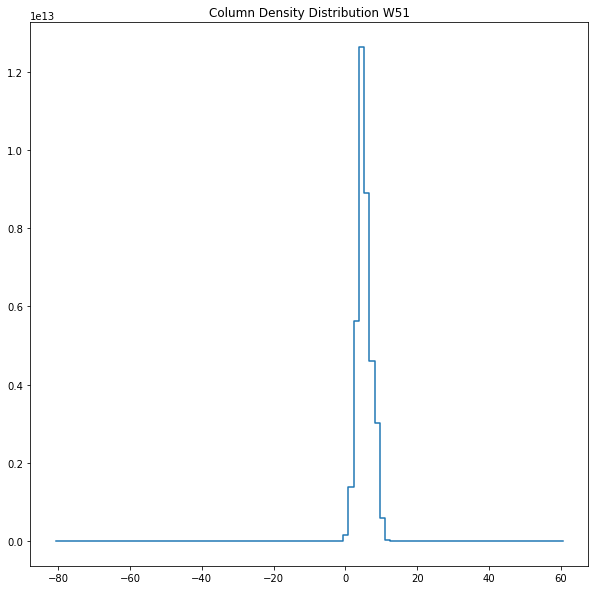

In [842]:
# Plot the Column Density Distribution:
fig, axs = plt.subplots(1, figsize=(10, 10))

axs.step(velnoh-25, dn_OH_tot)
axs.set_title('Column Density Distribution W51')
#axs.set_xlim([-20, 100])
#axs.set_ylim([0, 0.6e12])

In [843]:
# Get the best fit for plotting the combined fits:
y_fitsof = gauss_dataset_sof_n(out.params, n, VelSof)
y_fit67 = gauss_dataset_n(out.params, n, 0, vel67)
y_fit65 = gauss_dataset_n(out.params, n, 1, vel65)
y_fit12 = gauss_dataset_n(out.params, n, 2, vel12)
y_fit20 = gauss_dataset_n(out.params, n, 3, vel20)

In [844]:
# How do we get parameters:
out.params['cen1667_1_0'].value

5.999999983791575

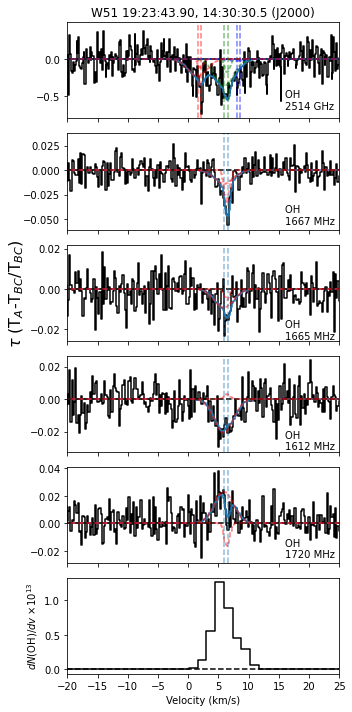

In [845]:
# What is the main beam efficiency for L-band VLA?

# Plot the data:
fig, axs = plt.subplots(6, figsize=(5, 10), sharex='all')

# Plot the OH:
axs[0].step(VelSof, (TaSof/10.1), 'k', label='OH 2.5 THz', where='mid')
axs[0].step(VelSof, y_fitsof, where='mid')
axs[0].axhline(0, color='k', ls='dashed')
axs[0].annotate('OH \n2514 GHz', xy=[16, -0.67])
#axs[0].axvspan(3, 9, color='grey', alpha=0.3, lw=0)
for i in range(n):
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='316', x=VelSof), alpha=0.5, ls='dashed', color='green')
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='298', x=VelSof), alpha=0.5, ls='dashed', color='blue')
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='353', x=VelSof), alpha=0.5, ls='dashed', color='red')
    axs[0].axvline(out.params[f'cen316_{i}'].value, ls='dashed', alpha=0.5, color='green')
    axs[0].axvline(out.params[f'cen298_{i}'].value, ls='dashed', alpha=0.5, color='blue')
    axs[0].axvline(out.params[f'cen353_{i}'].value, ls='dashed', alpha=0.5, color='red')

axs[1].step(vel67, (Ta67-Tc67)/Tc67, 'k', label='OH 1667 MHz', where='mid')
axs[1].step(vel67, y_fit67, where='mid')
axs[1].axhline(0, color='k', ls='dashed')
axs[1].annotate('OH \n1667 MHz', xy=[16, -0.055])
#axs[1].axvspan(3, 9, color='grey', alpha=0.3, lw=0)
for i in range(n):
    axs[1].step(vel67, gauss_dataset_VLA(out.params, i, 0 , x=vel67), alpha=0.5, ls='dashed', color='red')
    axs[1].axvline(out.params[f'cen1667_1_{i}'].value, ls='dashed', alpha=0.5)

axs[2].step(vel65, (Ta65-Tc65)/Tc65, 'k', label='OH 1665 MHz', where='mid')
axs[2].step(vel65, y_fit65, where='mid')
axs[2].axhline(0, color='k', ls='dashed')
axs[2].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[2].annotate('OH \n1665 MHz', xy=[16, -0.025])
#axs[2].axvspan(3, 9, color='grey', alpha=0.3, lw=0)
for i in range(n):
    axs[2].step(vel65, gauss_dataset_VLA(out.params, i, 1 , x=vel65), alpha=0.5, ls='dashed', color='red')
    axs[2].axvline(out.params[f'cen1665_2_{i}'].value, ls='dashed', alpha=0.5)

axs[3].step(vel12, (Ta12-Tc12)/Tc12, 'k', label='OH 1612 MHz', where='mid')
axs[3].step(vel12, y_fit12, where='mid')
axs[3].axhline(0, color='k', ls='dashed')
axs[3].annotate('OH \n1612 MHz', xy=[16, -0.031])
#axs[3].axvspan(3, 9, color='grey', alpha=0.3, lw=0)
for i in range(n):
    axs[3].step(vel12, gauss_dataset_VLA(out.params, i, 2 , x=vel12), alpha=0.5, ls='dashed', color='red')
    axs[3].axvline(out.params[f'cen1612_3_{i}'].value, ls='dashed', alpha=0.5)

axs[4].step(vel20, (Ta20-Tc20)/Tc20, 'k', label='OH 1720 MHz', where='mid')
axs[4].step(vel20, y_fit20, where='mid')
axs[4].axhline(0, color='k', ls='dashed')
axs[4].annotate('OH \n1720 MHz', xy=[16, -0.025])
#axs[4].axvspan(3, 9, color='grey', alpha=0.3, lw=0)
for i in range(n):
    axs[4].step(vel20, gauss_dataset_VLA(out.params, i, 3 , x=vel20), alpha=0.5, ls='dashed', color='red')
    axs[4].axvline(out.params[f'cen1720_4_{i}'].value, ls='dashed', alpha=0.5)

axs[5].step(velnoh-25, dn_OH_tot/1e13, 'k', where='mid')
#axs[5].axvspan(3, 9, color='grey', alpha=0.3, lw=0)
axs[5].axhline(0, color='k', ls='dashed')
axs[5].set_ylabel(r'$dN(\mathrm{OH})/dv$ $\times 10^{13}$')

axs[5].set_xlim([-20, 25])

plt.xlabel('Velocity (km/s)')
axs[0].set_title('W51 19:23:43.90, 14:30:30.5 (J2000)')

fig.tight_layout()
fig.savefig("W51_2components.pdf", format='pdf', dpi=400)
fig.savefig("W51_2components.png", format='png', dpi=400)

In [849]:
# Plot W49N:

# Load OH spectra toward W49N:

# Attempt to loading the SOFIA data:
ohsof = ascii.read('OH_data_deltav_0p1/W49N_OH_dv0p1.txt', format='csv', delimiter=' ', data_start=0, names=["Velo", "Tb"])
#w49noh_2 = ascii.read('Column_density_distributions/Column_density_distributions/coldens_OH_W49N.csv')
w49noh_real = ascii.read('Column_density_distributions/Column_density_distributions/coldens_OH_W49N.csv')

TaSof = ohsof["Tb"]
VelSof = ohsof["Velo"]

# Velocity Bounds being set:
up = 30
low = 80

igood = np.where((VelSof >= up) & (VelSof <= low))

TaSof = ohsof["Tb"][igood]
VelSof = ohsof["Velo"][igood]

# 3-2-1-4
# For W49N:
oh67 = ascii.read("VLAdata/VLASpectra/W49N/HYGAL_W49N_oh3_niter10000_threshold100mJybeam_highres_cube.20arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2023-12-10-23-38-35.tsv", format='tab', names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)
oh65 = ascii.read("VLAdata/VLASpectra/W49N/HYGAL_W49N_oh2_niter10000_threshold100mJybeam_highres_cube.20arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2023-12-10-23-38-35.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)
oh12 = ascii.read("VLAdata/VLASpectra/W49N/HYGAL_W49N_oh1_niter100000_threshold100mJybeam_highres_cube.20arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2023-12-10-23-38-35.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)
oh20 = ascii.read("VLAdata/VLASpectra/W49N/HYGAL_W49N_oh4_niter10000_threshold100mJybeam_highres_cube.20arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2023-12-10-23-38-35.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)

vel67 = oh67['VELO (km/s)']
Ta67 = oh67['Ta (K)']
vel65 = oh65['VELO (km/s)']
Ta65 = oh65['Ta (K)']
vel12 = oh12['VELO (km/s)']
Ta12 = oh12['Ta (K)']
vel20 = oh20['VELO (km/s)']
Ta20 = oh20['Ta (K)']
velnoh = w49noh_real['col1']
noh = w49noh_real['col2']

# Choose velocity range.
igood67 = np.where((vel67 >= up) & (vel67 <= low))
igood65 = np.where((vel65 >= up) & (vel65 <= low))
igood12 = np.where((vel12 >= up) & (vel12 <= low))
igood20 = np.where((vel20 >= up) & (vel20 <= low))
igoodnoh = np.where((velnoh-25 >= up) & (velnoh-25 <= low))

# Choose a continuum.
igood67c = np.where((vel67 >= 70) & (vel67 <= 80))
igood65c = np.where((vel65 >= 70) & (vel65 <= 80))
igood12c = np.where((vel12 >= 70) & (vel12 <= 80))
igood20c = np.where((vel20 >= 70) & (vel20 <= 80))

# Calculate median continuum temperature:
Tc67 = np.median(Ta67[igood67c])
Tc65 = np.median(Ta65[igood65c])
Tc12 = np.median(Ta12[igood12c])
Tc20 = np.median(Ta20[igood20c])

# Calculate standard deviation of Tau for VLA:
tauSigmaRadio = (Ta67-Tc67)/Tc67
tauSigmaRadio = np.std(tauSigmaRadio[igood67c])

# Calculate standard deviation of Tau for SOFIA:
tauSigmaSof = (TaSof/8)
tauSigmaSof = np.std(tauSigmaSof[igoodSofc])

# Limit velocity range:
vel67 = vel67[igood67]
Ta67 = Ta67[igood67]
vel65 = vel65[igood65]
Ta65 = Ta65[igood65]
vel12 = vel12[igood12]
Ta12 = Ta12[igood12]
vel20 = vel20[igood20]
Ta20 = Ta20[igood20]
velnoh = velnoh[igoodnoh]
noh = noh[igoodnoh]

# Load up the column density:

w49noh = ascii.read('XCLASS_fits/XCLASS_fits/OH_W49N.molfit')

Area_OH = w49noh['col1']

mu_OH = w49noh['col3']

sigma_OH = w49noh['col2']/2.3

A_OH = Area_OH/(w49noh['col2']*const)

dn_OH_tot = 0

for i in range(0, len(mu_OH)):
   dn_OH_tot = dn_OH_tot + gauss(velnoh, A_OH[i], mu_OH[i], sigma_OH[i])

# What is the column density?
delta = abs(velnoh[1]-velnoh[0])

# Component 1:
igoodnoh = np.where((velnoh-25 >= 38) & (velnoh-25 <= 42))
columnDensity1 = np.sum(dn_OH_tot[igoodnoh])*delta*u.cm**-2

# Component 2:
igoodnoh = np.where((velnoh-25 >= 58) & (velnoh-25 <= 60))
columnDensity2 = np.sum(dn_OH_tot[igoodnoh])*delta*u.cm**-2

# Component 3:
igoodnoh = np.where((velnoh-25 >= 60) & (velnoh-25 <= 62))
columnDensity3 = np.sum(dn_OH_tot[igoodnoh])*delta*u.cm**-2

In [850]:
print(tauSigmaRadio)
print(tauSigmaSof)

0.012595087154647673
0.20215902348607537


Text(0.5, 1.0, 'Column Density Distribution W49')

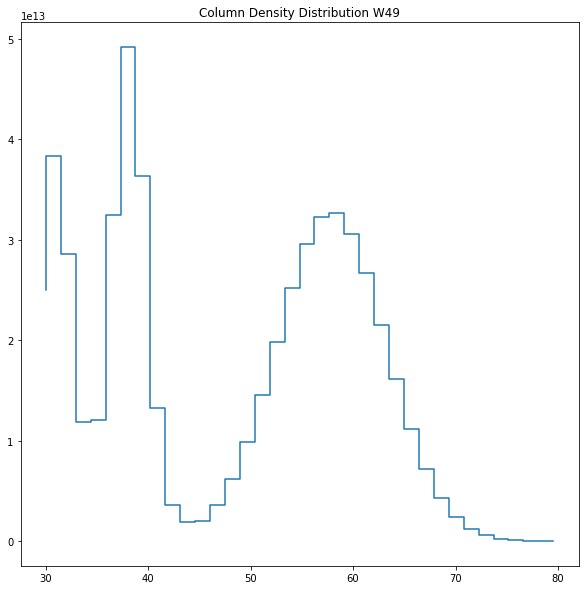

In [851]:
# Plot the Column Density Distribution:
fig, axs = plt.subplots(1, figsize=(10, 10))

axs.step(velnoh-25, dn_OH_tot)
axs.set_title('Column Density Distribution W49')
#axs.set_xlim([-20, 100])
#axs.set_ylim([0, 0.6e12])

In [854]:
# Fit the W51 data with a single component Gaussian for each line:
# Create two data arrays, one for VLA and one for Sofia:
dataVLA = [((Ta67-Tc67)/Tc67).value, ((Ta65-Tc65)/Tc65).value, ((Ta12-Tc12)/Tc12).value, ((Ta20-Tc20)/Tc20).value]
dataVLA = np.array(dataVLA)

dataSof = [(TaSof/8)]
dataSof = np.array(dataSof)

In [859]:
# Fitting W49N using 3 components:

# Number of gas components:
n=2

# Figure of Merits:
aic = []
bic = []

# Add in intitial guesses
c0 = [40, 60]
s0 = [2, 2]
aSof = [-0.5, -0.5]
a1667 = [-0.03,-0.03]
a1665 = [-0.025, -0.025]
a1612 = [-0.025,-0.025]
a1720 = [-0.03,-0.03]

# Add in sigma guess from 18cm line:

# Instantiate fit parameters:
fit_params = Parameters()

# Set parameters:
makeVLA(n, dataVLA, fit_params, c0, a1667, a1665, a1612, a1720, s0, lim=10)
makeSOFIA(n, dataSof, fit_params, c0, s0, aSof)

# Do the fitting
out = minimize(fcn=objective_n, params=fit_params, args=(n, vel67, VelSof, dataVLA, dataSof, tauSigmaRadio, tauSigmaSof), method='leastsq')
out

In [856]:
# We need the extent of the FWHM of the gaussians from the n(OH):
# FWHM = 2.355 * sigma.
# and the centers!

resultsTableW49 = pd.DataFrame(np.array([[0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0
                                         ]]),
                              columns = ['Source', 
                                         'Component', 
                                         'Line',
                                        'Peak',
                                        '\sigma Peak',
                                        'Center',
                                        '\sigma Center',
                                        'FWHM',
                                        '\sigma FWHM',
                                        'W',
                                        '\sigma W',
                                        'N(OH)',
                                        'Tex',
                                        '\sigma Tex'])

line = ['1667', '1665', '1612', '1720', '316', '298', '353']

for i in range(n):
    source = 'W49'
    comp = i
    for j in line:
        if j == '1667':
            l = 1
            
            # Get all values:
            Peak = out.params[f'amp{j}_{l}_{i}'].value
            sigPeak = out.params[f'amp{j}_{l}_{i}'].stderr
            Cen = out.params[f'cen{j}_{l}_{i}'].value
            sigCen = out.params[f'cen{j}_{l}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].stderr
            Wv = np.nan
            sigWv = np.nan
            
            igoodnoh = np.where((velnoh-25 >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (velnoh-25 <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(dn_OH_tot[igoodnoh])*delta
            
            k = 1
            Tex = -(0.45 * k * N_OH/1e14)/Wv
            sigTex = np.abs(Tex)*np.sqrt((sigWv/Wv)**2)
        elif j == '1665':
            l = 2
            
            # Get all values:
            Peak = out.params[f'amp{j}_{l}_{i}'].value
            sigPeak = out.params[f'amp{j}_{l}_{i}'].stderr
            Cen = out.params[f'cen{j}_{l}_{i}'].value
            sigCen = out.params[f'cen{j}_{l}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].stderr
            Wv = np.nan
            sigWv = np.nan
            
            igoodnoh = np.where((velnoh-25 >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (velnoh-25 <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(dn_OH_tot[igoodnoh])*delta
            
            k = 5/9
            Tex = -(0.45 * k * N_OH/1e14)/Wv
            sigTex = np.abs(Tex)*np.sqrt((sigWv/Wv)**2)
        elif j == '1612':
            l = 3
            
            # Get all values:
            Peak = out.params[f'amp{j}_{l}_{i}'].value
            sigPeak = out.params[f'amp{j}_{l}_{i}'].stderr
            Cen = out.params[f'cen{j}_{l}_{i}'].value
            sigCen = out.params[f'cen{j}_{l}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].stderr
            Wv = np.nan
            sigWv = np.nan
            
            igoodnoh = np.where((velnoh-25 >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (velnoh-25 <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(dn_OH_tot[igoodnoh])*delta
            
            k = 1/9
            Tex = -(0.45 * k * N_OH/1e14)/Wv
            sigTex = np.abs(Tex)*np.sqrt((sigWv/Wv)**2)
        elif j == '1720':
            l = 4
            
            # Get all values:
            Peak = out.params[f'amp{j}_{l}_{i}'].value
            sigPeak = out.params[f'amp{j}_{l}_{i}'].stderr
            Cen = out.params[f'cen{j}_{l}_{i}'].value
            sigCen = out.params[f'cen{j}_{l}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].stderr
            Wv = np.nan
            sigWv = np.nan
            
            igoodnoh = np.where((velnoh-25 >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (velnoh-25 <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(dn_OH_tot[igoodnoh])*delta
            
            k = 1/9
            Tex = -(0.45 * k * N_OH/1e14)/Wv
            sigTex = np.abs(Tex)*np.sqrt((sigWv/Wv)**2)
            
        elif j == '316':
            # Get all values:
            Peak = out.params[f'amp{j}_{i}'].value
            sigPeak = out.params[f'amp{j}_{i}'].stderr
            Cen = out.params[f'cen{j}_{i}'].value
            sigCen = out.params[f'cen{j}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{i}'].stderr
            Wv = np.nan
            sigWv = np.nan
            
            igoodnoh = np.where((velnoh-25 >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (velnoh-25 <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(dn_OH_tot[igoodnoh])*delta
            
            Tex = np.nan
            sigTex = np.nan
        elif j == '298':
            # Get all values:
            Peak = out.params[f'amp{j}_{i}'].value
            sigPeak = out.params[f'amp{j}_{i}'].stderr
            Cen = out.params[f'cen{j}_{i}'].value
            sigCen = out.params[f'cen{j}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{i}'].stderr
            Wv = np.nan
            sigWv = np.nan
            
            igoodnoh = np.where((velnoh-25 >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (velnoh-25 <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(dn_OH_tot[igoodnoh])*delta
            
            Tex = np.nan
            sigTex = np.nan
        elif j == '353':
            # Get all values:
            Peak = out.params[f'amp{j}_{i}'].value
            sigPeak = out.params[f'amp{j}_{i}'].stderr
            Cen = out.params[f'cen{j}_{i}'].value
            sigCen = out.params[f'cen{j}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{i}'].stderr
            Wv = np.nan
            sigWv = np.nan
            
            igoodnoh = np.where((velnoh-25 >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (velnoh-25 <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(dn_OH_tot[igoodnoh])*delta
            
            Tex = np.nan
            sigTex = np.nan
        
        resultsTableW49.loc[len(resultsTableW49.index)] = source, i, j, Peak, sigPeak, Cen, sigCen, fwhm, sigfwhm, Wv, sigWv, N_OH, Tex, sigTex

# Drop the first element:        
resultsTableW49 = resultsTableW49.drop(0)

TypeError: unsupported operand type(s) for *: 'float' and 'NoneType'

In [ ]:
resultsTableW49

In [598]:
# Get the best fit for plotting the combined fits:
y_fitsof = gauss_dataset_sof_n(out.params, n, VelSof)
y_fit67 = gauss_dataset_n(out.params, n, 0, vel67)
y_fit65 = gauss_dataset_n(out.params, n, 1, vel65)
y_fit12 = gauss_dataset_n(out.params, n, 2, vel12)
y_fit20 = gauss_dataset_n(out.params, n, 3, vel20)

Text(0.5, 1.0, 'W49N, 19:10:13.20, 09:06:12.0 (J2000)')

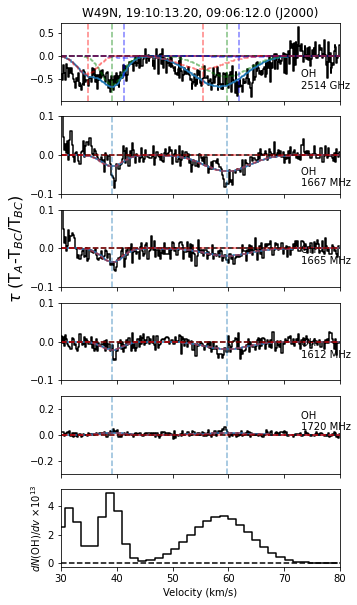

In [599]:
# Plot the data:
fig, axs = plt.subplots(6, figsize=(5, 10), sharex='all')

# Plot the OH:
axs[0].step(VelSof, (TaSof/8), 'k', label='OH 2.5 THz', where='mid')
axs[0].step(VelSof, y_fitsof, where='mid')
axs[0].axhline(0, color='k', ls='dashed')
axs[0].annotate('OH \n2514 GHz', xy=[73, -0.71])
for i in range(n):
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='316', x=VelSof), alpha=0.5, ls='dashed', color='green')
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='298', x=VelSof), alpha=0.5, ls='dashed', color='blue')
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='353', x=VelSof), alpha=0.5, ls='dashed', color='red')
    axs[0].axvline(out.params[f'cen316_{i}'].value, ls='dashed', alpha=0.5, color='green')
    axs[0].axvline(out.params[f'cen298_{i}'].value, ls='dashed', alpha=0.5, color='blue')
    axs[0].axvline(out.params[f'cen353_{i}'].value, ls='dashed', alpha=0.5, color='red')

axs[1].step(vel67, (Ta67-Tc67)/Tc67, 'k', label='OH 1667 MHz', where='mid')
axs[1].step(vel67, y_fit67, where='mid')
axs[1].axhline(0, color='k', ls='dashed')
axs[1].set_ylim([-0.1, 0.1])
axs[1].annotate('OH \n1667 MHz', xy=[73, -0.08])
for i in range(n):
    axs[1].step(vel67, gauss_dataset_VLA(out.params, i, 0 , x=vel67), alpha=0.5, ls='dashed', color='red')
    axs[1].axvline(out.params[f'cen1667_1_{i}'].value, ls='dashed', alpha=0.5)

axs[2].step(vel65, (Ta65-Tc65)/Tc65, 'k', label='OH 1665 MHz', where='mid')
axs[2].step(vel65, y_fit65, where='mid')
axs[2].axhline(0, color='k', ls='dashed')
axs[2].set_ylim([-0.1, 0.1])
axs[2].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[2].annotate('OH \n1665 MHz', xy=[73, -0.041])
for i in range(n):
    axs[2].step(vel65, gauss_dataset_VLA(out.params, i, 1 , x=vel65), alpha=0.5, ls='dashed', color='red')
    axs[2].axvline(out.params[f'cen1665_2_{i}'].value, ls='dashed', alpha=0.5)

axs[3].step(vel12, (Ta12-Tc12)/Tc12, 'k', label='OH 1612 MHz', where='mid')
axs[3].step(vel12, y_fit12, where='mid')
axs[3].set_ylim([-0.1, 0.1])
axs[3].axhline(0, color='k', ls='dashed')
axs[3].annotate('OH \n1612 MHz', xy=[73, -0.041])
for i in range(n):
    axs[3].step(vel12, gauss_dataset_VLA(out.params, i, 2 , x=vel12), alpha=0.5, ls='dashed', color='red')
    axs[3].axvline(out.params[f'cen1612_3_{i}'].value, ls='dashed', alpha=0.5)

axs[4].step(vel20, (Ta20-Tc20)/Tc20, 'k', label='OH 1720 MHz', where='mid')
axs[4].set_ylim([-0.3, 0.3])
axs[4].step(vel20, y_fit20, where='mid')
axs[4].axhline(0, color='k', ls='dashed')
axs[4].annotate('OH \n1720 MHz', xy=[73, 0.035])
for i in range(n):
    axs[4].step(vel20, gauss_dataset_VLA(out.params, i, 3 , x=vel20), alpha=0.5, ls='dashed', color='red')
    axs[4].axvline(out.params[f'cen1720_4_{i}'].value, ls='dashed', alpha=0.5)

axs[5].step(velnoh-25, dn_OH_tot/1e13, 'k', where='mid')
axs[5].axhline(0, color='k', ls='dashed')
axs[5].set_ylabel(r'$dN(\mathrm{OH})/dv$ $\times 10^{13}$')

axs[5].set_xlim([30, 80])

plt.xlabel('Velocity (km/s)')
axs[0].set_title('W49N, 19:10:13.20, 09:06:12.0 (J2000)')

In [860]:
# Load OH spectra toward G34.3:
# 3 components?

# Attempt to loading the SOFIA data:
#ohsof = ascii.read('ASCII_data_files/ASCII_data_files/W51E4_OH_2Pi32_velo.txt', format='csv', delimiter=' ', data_start=0, names=["Velo", "Tb"])
ohsof = ascii.read('OH_data_deltav_0p1/G34P_OH_dv0p1.txt', format='csv', delimiter=' ', data_start=0, names=["Velo", "Tb"])
g34noh = ascii.read('Column_density_distributions/Column_density_distributions/coldens_OH_G34P26.csv')

# Sofia spectrum is in Tmb
TaSof = ohsof["Tb"]
VelSof = ohsof["Velo"]

# Velocity Bounds being set:
up = -40
low = 40

igood = np.where((VelSof >= up) & (VelSof <= low))

TaSof = ohsof["Tb"][igood]
VelSof = ohsof["Velo"][igood]

# For G34:
oh67 = ascii.read("VLAdata/VLASpectra/G34.3/HYGAL_G34p3+0p2_oh3_niter10000_threshold100mJybeam_highres_cube.20arcsec.image.pbcor.fits-Z-profile-Region_2-Statistic_Mean-Coordinate_Current-2023-12-19-15-52-03.tsv", format='tab', names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)
oh65 = ascii.read("VLAdata/VLASpectra/G34.3/HYGAL_G34p3+0p2_oh2_niter10000_threshold100mJybeam_highres_cube.20arcsec.image.pbcor.fits-Z-profile-Region_2-Statistic_Mean-Coordinate_Current-2023-12-19-15-52-03.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)
oh12 = ascii.read("VLAdata/VLASpectra/G34.3/HYGAL_G34p3+0p2_oh1_niter100000_threshold100mJybeam_highres_cube.20arcsec.image.pbcor.fits-Z-profile-Region_2-Statistic_Mean-Coordinate_Current-2023-12-19-15-52-03.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)
oh20 = ascii.read("VLAdata/VLASpectra/G34.3/HYGAL_G34p3+0p2_oh4_niter10000_threshold100mJybeam_highres_cube.20arcsec.image.pbcor.fits-Z-profile-Region_2-Statistic_Mean-Coordinate_Current-2023-12-19-15-52-03.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)

vel67 = oh67['VELO (km/s)']
Ta67 = oh67['Ta (K)']
vel65 = oh65['VELO (km/s)']
Ta65 = oh65['Ta (K)']
vel12 = oh12['VELO (km/s)']
Ta12 = oh12['Ta (K)']
vel20 = oh20['VELO (km/s)']
Ta20 = oh20['Ta (K)']
# Check this velocity shift with Arshia:
velnoh = g34noh['col1']-20
noh = g34noh['col2']

# Choose velocity range.
igood67 = np.where((vel67 >= up) & (vel67 <= low))
igood65 = np.where((vel65 >= up) & (vel65 <= low))
igood12 = np.where((vel12 >= up) & (vel12 <= low))
igood20 = np.where((vel20 >= up) & (vel20 <= low))
igoodnoh = np.where((velnoh >= up) & (velnoh <= low))

# Choose a continuum.
igood67c = np.where((vel67 >= up) & (vel67 <= low))
igood65c = np.where((vel65 >= up) & (vel65 <= low))
igood12c = np.where((vel12 >= up) & (vel12 <= low))
igood20c = np.where((vel20 >= up) & (vel20 <= low))
igoodSofc = np.where((VelSof >= up) & (VelSof <= low))

# Calculate median continuum temperature:
Tc67 = np.median(Ta67[igood67c])
Tc65 = np.median(Ta65[igood65c])
Tc12 = np.median(Ta12[igood12c])
Tc20 = np.median(Ta20[igood20c])

# Calculate standard deviation of Tau for VLA:
tauSigmaRadio = (Ta67-Tc67)/Tc67
tauSigmaRadio = np.std(tauSigmaRadio[igood67c])

# Calculate standard deviation of Tau for SOFIA:
tauSigmaSof = (TaSof/8.2)
tauSigmaSof = np.std(tauSigmaSof[igoodSofc])

# Limit velocity range:
vel67 = vel67[igood67]
Ta67 = Ta67[igood67]
vel65 = vel65[igood65]
Ta65 = Ta65[igood65]
vel12 = vel12[igood12]
Ta12 = Ta12[igood12]
vel20 = vel20[igood20]
Ta20 = Ta20[igood20]
velnoh = velnoh[igoodnoh]
noh = noh[igoodnoh]

# OH Sofia and NOH for G34
ohsof_ogres = ascii.read('OH_data_deltav_0p1/G34P26_OH_2Pi32_velo.txt')
g34noh = ascii.read('XCLASS_fits/XCLASS_fits/OH_G34P26.molfit')

Area_OH = g34noh['col1']

mu_OH = g34noh['col3']

sigma_OH = g34noh['col2']/2.3

A_OH = Area_OH/(g34noh['col2']*const)

dn_OH_tot = 0

for i in range(0, len(mu_OH)):
   dn_OH_tot = dn_OH_tot + gauss(ohsof_ogres['col1'], A_OH[i], mu_OH[i], sigma_OH[i])

# What is the column density?
delta = abs(ohsof_ogres['col1'][1]-ohsof_ogres['col1'][0])

# Component 1:
igoodnoh = np.where((ohsof_ogres['col1']-20 >= 8) & (ohsof_ogres['col1']-20 <= 15))
columnDensity1 = np.sum(dn_OH_tot[igoodnoh])*delta

# Component 2:
igoodnoh = np.where((ohsof_ogres['col1']-20 >= 25) & (ohsof_ogres['col1']-20 <= 32))
columnDensity2 = np.sum(dn_OH_tot[igoodnoh])*delta

In [861]:
delta

1.4557569000000044

In [862]:
print(tauSigmaRadio)
print(tauSigmaSof)

0.01530208416505586
0.3025347596229886


In [863]:
# Fit the W51 data with a single component Gaussian for each line:
# Create two data arrays, one for VLA and one for Sofia:
dataVLA = [((Ta67-Tc67)/Tc67).value, ((Ta65-Tc65)/Tc65).value, ((Ta12-Tc12)/Tc12).value, ((Ta20-Tc20)/Tc20).value]
dataVLA = np.array(dataVLA)

dataSof = [(TaSof/8.2)]
dataSof = np.array(dataSof)

Text(0.5, 1.0, 'Column Density Distribution G34')

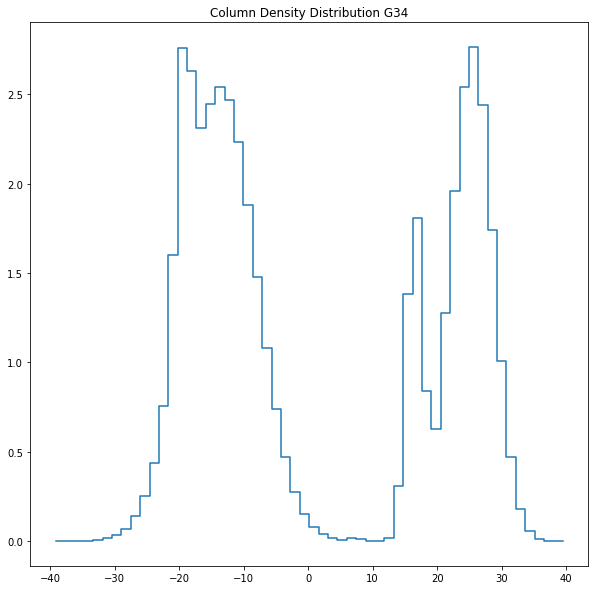

In [864]:
# Plot the Column Density Distribution:
fig, axs = plt.subplots(1, figsize=(10, 10))

axs.step(velnoh, noh/1e13)
axs.set_title('Column Density Distribution G34')
#axs.set_xlim([-20, 100])
#axs.set_ylim([0, 0.6e12])

In [866]:
# Fitting G34 using 2 components:

# Number of gas components:
n = 2

# Figure of Merits:
aic = []
bic = []

# Add in intitial guesses
c0 = [12, 25]
s0 = [3, 3]
aSof = [-0.5, -0.5]
a1667 = [-0.06, -0.05]
a1665 = [-0.05, -0.015]
a1612 = [-0.015, -0.015]
a1720 = [-0.025, -0.015]

# Add in sigma guess from 18cm line:

# Instantiate fit parameters:
fit_params = Parameters()

# Set parameters:
makeVLA(n, dataVLA, fit_params, c0, a1667, a1665, a1612, a1720, s0, lim=5)
makeSOFIA(n, dataSof, fit_params, c0, s0, aSof)

# Do the fitting
out = minimize(fcn=objective_n, params=fit_params, args=(n, vel67, VelSof, dataVLA, dataSof, tauSigmaRadio, tauSigmaSof), method='leastsq')
out

In [869]:
# We need the extent of the FWHM of the gaussians from the n(OH):
# FWHM = 2.355 * sigma.
# and the centers!

resultsTableG34 = pd.DataFrame(np.array([[0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0
                                         ]]),
                              columns = ['Source', 
                                         'Component', 
                                         'Line',
                                        'Peak',
                                        '\sigma Peak',
                                        'Center',
                                        '\sigma Center',
                                        'FWHM',
                                        '\sigma FWHM',
                                        'W',
                                        '\sigma W',
                                        'N(OH)',
                                        'Tex',
                                        '\sigma Tex'])

line = ['1667', '1665', '1612', '1720', '316', '298', '353']

for i in range(n):
    source = 'G34'
    comp = i
    for j in line:
        if j == '1667':
            l = 1
            
            # Get all values:
            Peak = out.params[f'amp{j}_{l}_{i}'].value
            sigPeak = out.params[f'amp{j}_{l}_{i}'].stderr
            Cen = out.params[f'cen{j}_{l}_{i}'].value
            sigCen = out.params[f'cen{j}_{l}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].stderr
            Wv = np.nan
            sigWv = np.nan
            
            igoodnoh = np.where((ohsof_ogres['col1']-20 >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (ohsof_ogres['col1']-20 <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(dn_OH_tot[igoodnoh])*delta
            
            k = 1
            Tex = -(0.45 * k * N_OH/1e14)/Peak
            sigTex = np.abs(Tex)*np.sqrt((sigPeak/Peak)**2)
        elif j == '1665':
            l = 2
            
            # Get all values:
            Peak = out.params[f'amp{j}_{l}_{i}'].value
            sigPeak = out.params[f'amp{j}_{l}_{i}'].stderr
            Cen = out.params[f'cen{j}_{l}_{i}'].value
            sigCen = out.params[f'cen{j}_{l}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].stderr
            Wv = np.nan
            sigWv = np.nan
            
            igoodnoh = np.where((ohsof_ogres['col1']-20 >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (ohsof_ogres['col1']-20 <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(dn_OH_tot[igoodnoh])*delta
            
            k = 5/9
            Tex = -(0.45 * k * N_OH/1e14)/Peak
            sigTex = np.abs(Tex)*np.sqrt((sigPeak/Peak)**2)
        elif j == '1612':
            l = 3
            
            # Get all values:
            Peak = out.params[f'amp{j}_{l}_{i}'].value
            sigPeak = out.params[f'amp{j}_{l}_{i}'].stderr
            Cen = out.params[f'cen{j}_{l}_{i}'].value
            sigCen = out.params[f'cen{j}_{l}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].stderr
            Wv = np.nan
            sigWv = np.nan
            
            igoodnoh = np.where((ohsof_ogres['col1']-20 >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (ohsof_ogres['col1']-20 <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(dn_OH_tot[igoodnoh])*delta
            
            k = 1/9
            Tex = -(0.45 * k * N_OH/1e14)/Peak
            sigTex = np.abs(Tex)*np.sqrt((sigPeak/Peak)**2)
        elif j == '1720':
            l = 4
            
            # Get all values:
            Peak = out.params[f'amp{j}_{l}_{i}'].value
            sigPeak = out.params[f'amp{j}_{l}_{i}'].stderr
            Cen = out.params[f'cen{j}_{l}_{i}'].value
            sigCen = out.params[f'cen{j}_{l}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].stderr
            Wv = np.nan
            sigWv = np.nan
            
            igoodnoh = np.where((ohsof_ogres['col1']-20 >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (ohsof_ogres['col1']-20 <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(dn_OH_tot[igoodnoh])*delta
            
            k = 1/9
            Tex = -(0.45 * k * N_OH/1e14)/Peak
            sigTex = np.abs(Tex)*np.sqrt((sigPeak/Peak)**2)
            
        elif j == '316':
            # Get all values:
            Peak = out.params[f'amp{j}_{i}'].value
            sigPeak = out.params[f'amp{j}_{i}'].stderr
            Cen = out.params[f'cen{j}_{i}'].value
            sigCen = out.params[f'cen{j}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{i}'].stderr
            Wv = np.nan
            sigWv = np.nan
            
            igoodnoh = np.where((ohsof_ogres['col1']-20 >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (ohsof_ogres['col1']-20 <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(dn_OH_tot[igoodnoh])*delta
            
            Tex = np.nan
            sigTex = np.nan
        elif j == '298':
            # Get all values:
            Peak = out.params[f'amp{j}_{i}'].value
            sigPeak = out.params[f'amp{j}_{i}'].stderr
            Cen = out.params[f'cen{j}_{i}'].value
            sigCen = out.params[f'cen{j}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{i}'].stderr
            Wv = np.nan
            sigWv = np.nan
            
            igoodnoh = np.where((ohsof_ogres['col1']-20 >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (ohsof_ogres['col1']-20 <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(dn_OH_tot[igoodnoh])*delta
            
            Tex = np.nan
            sigTex = np.nan
        elif j == '353':
            # Get all values:
            Peak = out.params[f'amp{j}_{i}'].value
            sigPeak = out.params[f'amp{j}_{i}'].stderr
            Cen = out.params[f'cen{j}_{i}'].value
            sigCen = out.params[f'cen{j}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{i}'].stderr
            Wv = np.nan
            sigWv = np.nan
            
            igoodnoh = np.where((ohsof_ogres['col1']-20 >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (ohsof_ogres['col1']-20 <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(dn_OH_tot[igoodnoh])*delta
            
            Tex = np.nan
            sigTex = np.nan
        
        resultsTableG34.loc[len(resultsTableG34.index)] = source, i, j, Peak, sigPeak, Cen, sigCen, fwhm, sigfwhm, Wv, sigWv, N_OH, Tex, sigTex

# Drop the first element:        
resultsTableG34 = resultsTableG34.drop(0)

In [870]:
resultsTableG34

,Source,Component,Line,Peak,\sigma Peak,Center,\sigma Center,FWHM,\sigma FWHM,W,\sigma W,N(OH),Tex,\sigma Tex
1,G34,0,1667,-0.114673,0.009629,11.710192,0.062524,2.131425,0.143375,NaN,NaN,8.237370e+13,3.232506,0.271432
2,G34,0,1665,-0.088444,0.009311,11.710192,0.062524,2.131425,0.143375,NaN,NaN,8.237370e+13,2.328416,0.245122
3,G34,0,1612,-0.009079,0.008828,11.710192,0.062524,2.131425,0.143375,NaN,NaN,8.237370e+13,4.536365,4.410896
4,G34,0,1720,-0.034181,0.008897,11.710192,0.062524,2.131425,0.143375,NaN,NaN,8.237370e+13,1.204976,0.313663
5,G34,0,316,-1.500000,0.889392,11.710192,0.062524,2.131425,0.143375,NaN,NaN,8.237370e+13,NaN,NaN
6,G34,0,298,-0.106500,0.063147,13.780192,0.062524,2.131425,0.143375,NaN,NaN,9.484690e+13,NaN,NaN
7,G34,0,353,-0.960000,0.569211,7.310192,0.062524,2.131425,0.143375,NaN,NaN,8.722099e+12,NaN,NaN
8,G34,1,1667,-0.061900,0.010288,27.461121,0.128966,2.628222,0.266337,NaN,NaN,6.044669e+13,4.394335,0.730343
9,G34,1,1665,-0.023097,0.009868,27.461121,0.128966,2.628222,0.266337,NaN,NaN,6.044669e+13,6.542639,2.795167
10,G34,1,1612,-0.022609,0.009865,27.461121,0.128966,2.628222,0.266337,NaN,NaN,6.044669e+13,1.336796,0.583262


In [871]:
# Get the best fit for plotting the combined fits:
y_fitsof = gauss_dataset_sof_n(out.params, n, VelSof)
y_fit67 = gauss_dataset_n(out.params, n, 0, vel67)
y_fit65 = gauss_dataset_n(out.params, n, 1, vel65)
y_fit12 = gauss_dataset_n(out.params, n, 2, vel12)
y_fit20 = gauss_dataset_n(out.params, n, 3, vel20)

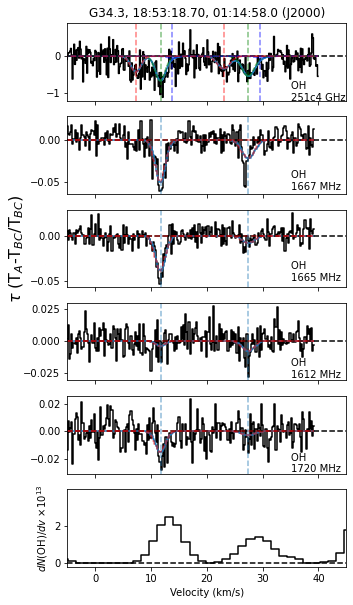

In [872]:
# What is the main beam efficiency for L-band VLA?
# 2 components

# Plot the data:
fig, axs = plt.subplots(6, figsize=(5, 10), sharex='all')

# Plot the OH:
axs[0].step(VelSof, (TaSof/8.2), 'k', label='OH 2.5 THz', where='mid')
axs[0].step(VelSof, y_fitsof, where='mid')
axs[0].axhline(0, color='k', ls='dashed')
axs[0].annotate('OH \n251c4 GHz', xy=[35, -1.2])
for i in range(n):
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='316', x=VelSof), alpha=0.5, ls='dashed', color='green')
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='298', x=VelSof), alpha=0.5, ls='dashed', color='blue')
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='353', x=VelSof), alpha=0.5, ls='dashed', color='red')
    axs[0].axvline(out.params[f'cen316_{i}'].value, ls='dashed', alpha=0.5, color='green')
    axs[0].axvline(out.params[f'cen298_{i}'].value, ls='dashed', alpha=0.5, color='blue')
    axs[0].axvline(out.params[f'cen353_{i}'].value, ls='dashed', alpha=0.5, color='red')

axs[1].step(vel67, (Ta67-Tc67)/Tc67, 'k', label='OH 1667 MHz', where='mid')
axs[1].step(vel67, y_fit67, where='mid')
axs[1].axhline(0, color='k', ls='dashed')
axs[1].annotate('OH \n1667 MHz', xy=[35, -0.06])
for i in range(n):
    axs[1].step(vel67, gauss_dataset_VLA(out.params, i, 0 , x=vel67), alpha=0.5, ls='dashed', color='red')
    axs[1].axvline(out.params[f'cen1667_1_{i}'].value, ls='dashed', alpha=0.5)

axs[2].step(vel65, (Ta65-Tc65)/Tc65, 'k', label='OH 1665 MHz', where='mid')
axs[2].step(vel65, y_fit65, where='mid')
axs[2].axhline(0, color='k', ls='dashed')
axs[2].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[2].annotate('OH \n1665 MHz', xy=[35, -0.05])
for i in range(n):
    axs[2].step(vel65, gauss_dataset_VLA(out.params, i, 1 , x=vel65), alpha=0.5, ls='dashed', color='red')
    axs[2].axvline(out.params[f'cen1665_2_{i}'].value, ls='dashed', alpha=0.5)

axs[3].step(vel12, (Ta12-Tc12)/Tc12, 'k', label='OH 1612 MHz', where='mid')
axs[3].step(vel12, y_fit12, where='mid')
axs[3].axhline(0, color='k', ls='dashed')
axs[3].annotate('OH \n1612 MHz', xy=[35, -0.029])
for i in range(n):
    axs[3].step(vel12, gauss_dataset_VLA(out.params, i, 2 , x=vel12), alpha=0.5, ls='dashed', color='red')
    axs[3].axvline(out.params[f'cen1612_3_{i}'].value, ls='dashed', alpha=0.5)

axs[4].step(vel20, (Ta20-Tc20)/Tc20, 'k', label='OH 1720 MHz', where='mid')
axs[4].step(vel20, y_fit20, where='mid')
axs[4].axhline(0, color='k', ls='dashed')
axs[4].annotate('OH \n1720 MHz', xy=[35, -0.030])
for i in range(n):
    axs[4].step(vel20, gauss_dataset_VLA(out.params, i, 3 , x=vel20), alpha=0.5, ls='dashed', color='red')
    axs[4].axvline(out.params[f'cen1720_4_{i}'].value, ls='dashed', alpha=0.5)

axs[5].step(ohsof_ogres['col1']-20, dn_OH_tot/1e13, 'k', where='mid')
axs[5].axhline(0, color='k', ls='dashed')
axs[5].set_ylabel(r'$dN(\mathrm{OH})/dv$ $\times 10^{13}$')

axs[5].set_xlim([-5, 45])

plt.xlabel('Velocity (km/s)')
axs[0].set_title('G34.3, 18:53:18.70, 01:14:58.0 (J2000)')
fig.savefig("G34_2components.pdf", format='pdf', dpi=400)
fig.savefig("G34_2components.png", format='png', dpi=400)

### HyGAL Sources:
#### W3 IRS5, G10.47, DR21, G29.96, G32.80

In [645]:
# Load and plot G10.47

# Load OH spectra toward G10.47:

# Attempt to loading the SOFIA data:
#ohsof = ascii.read('ASCII_data_files/ASCII_data_files/W51E4_OH_2Pi32_velo.txt', format='csv', delimiter=' ', data_start=0, names=["Velo", "Tb"])
ohsof = ascii.read('ASCII_data_files/G10.47+0.03/ASCII files/G10P47_OH.spec', format='csv', delimiter=' ', data_start=4, names=["Velo", "Tb"])
g10noh = ascii.read('Column_density_distributions/OH_For_Michael_Busch/column_density_files/Noh_G10P47.txt')

# Sofia spectrum is in Tmb
TaSof = ohsof["Tb"]
VelSof = ohsof["Velo"]

# Velocity Bounds being set:
up = -100
low = 100

igood = np.where((VelSof >= up) & (VelSof <= low))

TaSof = ohsof["Tb"][igood]
VelSof = ohsof["Velo"][igood]

# For G10.47:
oh67 = ascii.read("VLAdata/VLASpectra/G10.47/HYGAL_G10p47+0p03_oh3_niter10000_threshold100mJybeam_highres_cube.30arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2023-12-10-23-56-48.tsv", format='tab', names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)
oh65 = ascii.read("VLAdata/VLASpectra/G10.47/HYGAL_G10p47+0p03_oh2_niter10000_threshold100mJybeam_highres_cube.30arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2023-12-10-23-56-48.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)
oh12 = ascii.read("VLAdata/VLASpectra/G10.47/HYGAL_G10p47+0p03_oh1_niter100000_threshold100mJybeam_highres_cube.30arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2023-12-10-23-56-48.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)
oh20 = ascii.read("VLAdata/VLASpectra/G10.47/HYGAL_G10p47+0p03_oh4_niter10000_threshold100mJybeam_highres_cube.30arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2023-12-10-23-56-48.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)

vel67 = oh67['VELO (km/s)']
Ta67 = oh67['Ta (K)']
vel65 = oh65['VELO (km/s)']
Ta65 = oh65['Ta (K)']
vel12 = oh12['VELO (km/s)']
Ta12 = oh12['Ta (K)']
vel20 = oh20['VELO (km/s)']
Ta20 = oh20['Ta (K)']
# Check this velocity shift with Arshia:
velnoh = g10noh['col1']+2
noh = g10noh['col2']

# Choose velocity range.
igood67 = np.where((vel67 >= up) & (vel67 <= low))
igood65 = np.where((vel65 >= up) & (vel65 <= low))
igood12 = np.where((vel12 >= up) & (vel12 <= low))
igood20 = np.where((vel20 >= up) & (vel20 <= low))
igoodnoh = np.where((velnoh >= up) & (velnoh <= low))

# Choose a continuum.
igood67c = np.where((vel67 >= up) & (vel67 <= low))
igood65c = np.where((vel65 >= up) & (vel65 <= low))
igood12c = np.where((vel12 >= up) & (vel12 <= low))
igood20c = np.where((vel20 >= up) & (vel20 <= low))
igoodSofc = np.where((VelSof >= up) & (VelSof <= low))

# Calculate median continuum temperature:
Tc67 = np.median(Ta67[igood67c])
Tc65 = np.median(Ta65[igood65c])
Tc12 = np.median(Ta12[igood12c])
Tc20 = np.median(Ta20[igood20c])

# Calculate standard deviation of Tau for VLA:
tauSigmaRadio = (Ta67-Tc67)/Tc67
tauSigmaRadio = np.std(tauSigmaRadio[igood67c])

# Calculate standard deviation of Tau for SOFIA:
tauSigmaSof = (TaSof/7.88)
tauSigmaSof = np.std(tauSigmaSof[igoodSofc])

# Limit velocity range:
vel67 = vel67[igood67]
Ta67 = Ta67[igood67]
vel65 = vel65[igood65]
Ta65 = Ta65[igood65]
vel12 = vel12[igood12]
Ta12 = Ta12[igood12]
vel20 = vel20[igood20]
Ta20 = Ta20[igood20]
velnoh = velnoh[igoodnoh]
noh = noh[igoodnoh]

In [646]:
print(tauSigmaRadio)
print(tauSigmaSof)

0.05379883852646279
0.3392612531832458


In [647]:
# Fit the W51 data with a single component Gaussian for each line:
# Create two data arrays, one for VLA and one for Sofia:
dataVLA = [((Ta67-Tc67)/Tc67).value, ((Ta65-Tc65)/Tc65).value, ((Ta12-Tc12)/Tc12).value, ((Ta20-Tc20)/Tc20).value]
dataVLA = np.array(dataVLA)

dataSof = [((TaSof-7.88)/7.88)]
dataSof = np.array(dataSof)

Text(0.5, 1.0, 'Column Density Distribution G10.47')

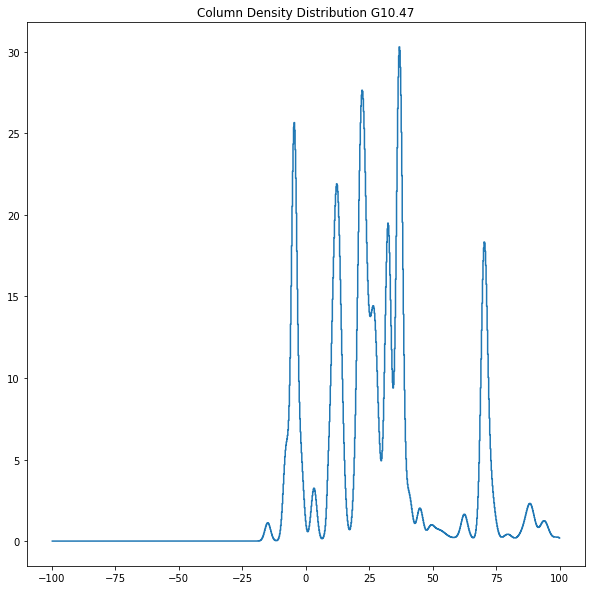

In [648]:
# Plot the Column Density Distribution:
fig, axs = plt.subplots(1, figsize=(10, 10))

axs.step(velnoh, noh/1e13)
axs.set_title('Column Density Distribution G10.47')
#axs.set_xlim([-20, 100])
#axs.set_ylim([0, 0.6e12])

In [649]:
# Fitting G10 using 2 components:

# Number of gas components:
n = 1

# Figure of Merits:
aic = []
bic = []

# Add in intitial guesses
c0 = [70]
s0 = [3]
aSof = [-0.5]
a1667 = [-0.2]
a1665 = [-0.3]
a1612 = [-0.2]
a1720 = [0.2]

# Add in sigma guess from 18cm line:

# Instantiate fit parameters:
fit_params = Parameters()

# Set parameters:
makeVLA(n, dataVLA, fit_params, c0, a1667, a1665, a1612, a1720, s0, lim=5)
makeSOFIA(n, dataSof, fit_params, c0, s0, aSof)

# Do the fitting
out = minimize(fcn=objective_n, params=fit_params, args=(n, vel67, VelSof, dataVLA, dataSof, tauSigmaRadio, tauSigmaSof), method='leastsq')
out

In [650]:
# We need the extent of the FWHM of the gaussians from the n(OH):
# FWHM = 2.355 * sigma.
# and the centers!

resultsTableG10 = pd.DataFrame(np.array([[0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0
                                         ]]),
                              columns = ['Source', 
                                         'Component', 
                                         'Line',
                                        'Peak',
                                        '\sigma Peak',
                                        'Center',
                                        '\sigma Center',
                                        'FWHM',
                                        '\sigma FWHM',
                                        'W',
                                        '\sigma W',
                                        'N(OH)',
                                        'Tex',
                                        '\sigma Tex'])

line = ['1667', '1665', '1612', '1720', '316', '298', '353']

for i in range(n):
    source = 'G10'
    comp = i
    for j in line:
        if j == '1667':
            l = 1
            
            # Get all values:
            Peak = out.params[f'amp{j}_{l}_{i}'].value
            sigPeak = out.params[f'amp{j}_{l}_{i}'].stderr
            Cen = out.params[f'cen{j}_{l}_{i}'].value
            sigCen = out.params[f'cen{j}_{l}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].stderr
            Wv = out.params[f'W{j}_{l}_{i}'].value
            sigWv = out.params[f'W{j}_{l}_{i}'].stderr
            
            igoodnoh = np.where((velnoh >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (velnoh <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(noh[igoodnoh])*delta
            
            k = 1
            Tex = -(0.45 * k * N_OH/1e14)/Wv
            sigTex = np.abs(Tex)*np.sqrt((sigWv/Wv)**2)
        elif j == '1665':
            l = 2
            
            # Get all values:
            Peak = out.params[f'amp{j}_{l}_{i}'].value
            sigPeak = out.params[f'amp{j}_{l}_{i}'].stderr
            Cen = out.params[f'cen{j}_{l}_{i}'].value
            sigCen = out.params[f'cen{j}_{l}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].stderr
            Wv = out.params[f'W{j}_{l}_{i}'].value
            sigWv = out.params[f'W{j}_{l}_{i}'].stderr
            
            igoodnoh = np.where((velnoh >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (velnoh <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(noh[igoodnoh])*delta
            
            k = 5/9
            Tex = -(0.45 * k * N_OH/1e14)/Wv
            sigTex = np.abs(Tex)*np.sqrt((sigWv/Wv)**2)
        elif j == '1612':
            l = 3
            
            # Get all values:
            Peak = out.params[f'amp{j}_{l}_{i}'].value
            sigPeak = out.params[f'amp{j}_{l}_{i}'].stderr
            Cen = out.params[f'cen{j}_{l}_{i}'].value
            sigCen = out.params[f'cen{j}_{l}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].stderr
            Wv = out.params[f'W{j}_{l}_{i}'].value
            sigWv = out.params[f'W{j}_{l}_{i}'].stderr
            
            igoodnoh = np.where((velnoh >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (velnoh <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(noh[igoodnoh])*delta
            
            k = 1/9
            Tex = -(0.45 * k * N_OH/1e14)/Wv
            sigTex = np.abs(Tex)*np.sqrt((sigWv/Wv)**2)
        elif j == '1720':
            l = 4
            
            # Get all values:
            Peak = out.params[f'amp{j}_{l}_{i}'].value
            sigPeak = out.params[f'amp{j}_{l}_{i}'].stderr
            Cen = out.params[f'cen{j}_{l}_{i}'].value
            sigCen = out.params[f'cen{j}_{l}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].stderr
            Wv = out.params[f'W{j}_{l}_{i}'].value
            sigWv = out.params[f'W{j}_{l}_{i}'].stderr
            
            igoodnoh = np.where((velnoh >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (velnoh <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(noh[igoodnoh])*delta
            
            k = 1/9
            Tex = -(0.45 * k * N_OH/1e14)/Wv
            sigTex = np.abs(Tex)*np.sqrt((sigWv/Wv)**2)
            
        elif j == '316':
            # Get all values:
            Peak = out.params[f'amp{j}_{i}'].value
            sigPeak = out.params[f'amp{j}_{i}'].stderr
            Cen = out.params[f'cen{j}_{i}'].value
            sigCen = out.params[f'cen{j}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{i}'].stderr
            Wv = out.params[f'W{j}_{i}'].value
            sigWv = out.params[f'W{j}_{i}'].stderr
            
            igoodnoh = np.where((velnoh >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (velnoh <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(noh[igoodnoh])*delta
            
            Tex = np.nan
            sigTex = np.nan
        elif j == '298':
            # Get all values:
            Peak = out.params[f'amp{j}_{i}'].value
            sigPeak = out.params[f'amp{j}_{i}'].stderr
            Cen = out.params[f'cen{j}_{i}'].value
            sigCen = out.params[f'cen{j}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{i}'].stderr
            Wv = out.params[f'W{j}_{i}'].value
            sigWv = out.params[f'W{j}_{i}'].stderr
            
            igoodnoh = np.where((velnoh >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (velnoh <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(noh[igoodnoh])*delta
            
            Tex = np.nan
            sigTex = np.nan
        elif j == '353':
            # Get all values:
            Peak = out.params[f'amp{j}_{i}'].value
            sigPeak = out.params[f'amp{j}_{i}'].stderr
            Cen = out.params[f'cen{j}_{i}'].value
            sigCen = out.params[f'cen{j}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{i}'].stderr
            Wv = out.params[f'W{j}_{i}'].value
            sigWv = out.params[f'W{j}_{i}'].stderr
            
            igoodnoh = np.where((velnoh >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (velnoh <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(noh[igoodnoh])*delta
            
            Tex = np.nan
            sigTex = np.nan
        
        resultsTableG10.loc[len(resultsTableG10.index)] = source, i, j, Peak, sigPeak, Cen, sigCen, fwhm, sigfwhm, Wv, sigWv, N_OH, Tex, sigTex

# Drop the first element:        
resultsTableG10 = resultsTableG10.drop(0)

In [651]:
resultsTableG10

,Source,Component,Line,Peak,\sigma Peak,Center,\sigma Center,FWHM,\sigma FWHM,W,\sigma W,N(OH),Tex,\sigma Tex
1,G10,0,1667,-0.203036,0.013596,69.912438,0.074653,3.899643,0.173555,-0.842812,0.056439,4.651205e+15,24.834036,1.663008
2,G10,0,1665,-0.248504,0.013965,69.912438,0.074653,3.899643,0.173555,-1.031550,0.057970,4.651205e+15,11.272372,0.633474
3,G10,0,1612,-0.169169,0.013364,69.912438,0.074653,3.899643,0.173555,-0.702225,0.055478,4.651205e+15,3.311760,0.261640
4,G10,0,1720,0.143011,0.013212,69.912438,0.074653,3.899643,0.173555,0.593646,0.054846,4.651205e+15,-3.917491,0.361933
5,G10,0,316,-0.676757,0.066011,69.912438,0.074653,3.899643,0.173555,-2.809248,0.259403,4.651205e+15,NaN,NaN
6,G10,0,298,-0.048050,0.004687,71.982438,0.074653,3.899643,0.173555,-0.199457,0.018418,4.676637e+15,NaN,NaN
7,G10,0,353,-0.433125,0.042247,65.512438,0.074653,3.899643,0.173555,-1.797919,0.166018,1.712351e+15,NaN,NaN


In [652]:
# Get the best fit for plotting the combined fits:
y_fitsof = gauss_dataset_sof_n(out.params, n, VelSof)
y_fit67 = gauss_dataset_n(out.params, n, 0, vel67)
y_fit65 = gauss_dataset_n(out.params, n, 1, vel65)
y_fit12 = gauss_dataset_n(out.params, n, 2, vel12)
y_fit20 = gauss_dataset_n(out.params, n, 3, vel20)

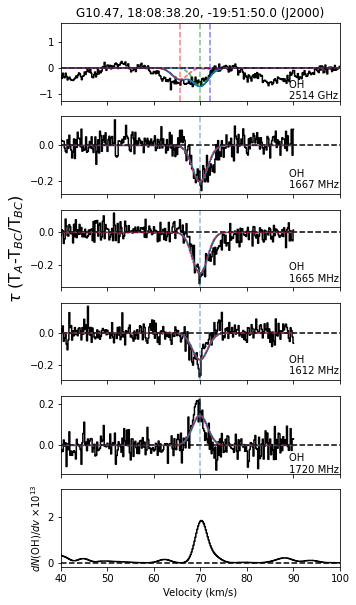

In [653]:
# What is the main beam efficiency for L-band VLA?
# What is the reference velocity?


# Plot the data:
fig, axs = plt.subplots(6, figsize=(5, 10), sharex='all')

# Plot the OH:
axs[0].step(VelSof, ((TaSof-7.88)/7.88), 'k', label='OH 2.5 THz', where='mid')
axs[0].step(VelSof, y_fitsof, where='mid')
axs[0].axhline(0, color='k', ls='dashed')
axs[0].annotate('OH \n2514 GHz', xy=[89, -1.2])
for i in range(n):
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='316', x=VelSof), alpha=0.5, ls='dashed', color='green')
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='298', x=VelSof), alpha=0.5, ls='dashed', color='blue')
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='353', x=VelSof), alpha=0.5, ls='dashed', color='red')
    axs[0].axvline(out.params[f'cen316_{i}'].value, ls='dashed', alpha=0.5, color='green')
    axs[0].axvline(out.params[f'cen298_{i}'].value, ls='dashed', alpha=0.5, color='blue')
    axs[0].axvline(out.params[f'cen353_{i}'].value, ls='dashed', alpha=0.5, color='red')

axs[1].step(vel67, (Ta67-Tc67)/Tc67, 'k', label='OH 1667 MHz', where='mid')
axs[1].step(vel67, y_fit67, where='mid')
axs[1].axhline(0, color='k', ls='dashed')
axs[1].annotate('OH \n1667 MHz', xy=[89, -0.24])
for i in range(n):
    axs[1].step(vel67, gauss_dataset_VLA(out.params, i, 0 , x=vel67), alpha=0.5, ls='dashed', color='red')
    axs[1].axvline(out.params[f'cen1667_1_{i}'].value, ls='dashed', alpha=0.5)

axs[2].step(vel65, (Ta65-Tc65)/Tc65, 'k', label='OH 1665 MHz', where='mid')
axs[2].step(vel65, y_fit65, where='mid')
axs[2].axhline(0, color='k', ls='dashed')
axs[2].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[2].annotate('OH \n1665 MHz', xy=[89, -0.3])
for i in range(n):
    axs[2].step(vel65, gauss_dataset_VLA(out.params, i, 1 , x=vel65), alpha=0.5, ls='dashed', color='red')
    axs[2].axvline(out.params[f'cen1665_2_{i}'].value, ls='dashed', alpha=0.5)

axs[3].step(vel12, (Ta12-Tc12)/Tc12, 'k', label='OH 1612 MHz', where='mid')
axs[3].step(vel12, y_fit12, where='mid')
axs[3].axhline(0, color='k', ls='dashed')
axs[3].annotate('OH \n1612 MHz', xy=[89, -0.26])
for i in range(n):
    axs[3].step(vel12, gauss_dataset_VLA(out.params, i, 2 , x=vel12), alpha=0.5, ls='dashed', color='red')
    axs[3].axvline(out.params[f'cen1612_3_{i}'].value, ls='dashed', alpha=0.5)

axs[4].step(vel20, (Ta20-Tc20)/Tc20, 'k', label='OH 1720 MHz', where='mid')
axs[4].step(vel20, y_fit20, where='mid')
axs[4].axhline(0, color='k', ls='dashed')
axs[4].annotate('OH \n1720 MHz', xy=[89, -0.13])
for i in range(n):
    axs[4].step(vel20, gauss_dataset_VLA(out.params, i, 3 , x=vel20), alpha=0.5, ls='dashed', color='red')
    axs[4].axvline(out.params[f'cen1720_4_{i}'].value, ls='dashed', alpha=0.5)

axs[5].step(velnoh, noh/1e14, 'k', where='mid')
axs[5].axhline(0, color='k', ls='dashed')
axs[5].set_ylabel(r'$dN(\mathrm{OH})/dv$ $\times 10^{13}$')

axs[5].set_xlim([40, 100])

plt.xlabel('Velocity (km/s)')
axs[0].set_title('G10.47, 18:08:38.20, -19:51:50.0 (J2000)')
fig.savefig("G1047_1components.pdf", format='pdf', dpi=400)
fig.savefig("G1047_1components.png", format='png', dpi=400)

In [873]:
# Plotting W3 IRS5:
# 1 components

# Load OH spectra toward W3 IRS5:

# Attempt to loading the SOFIA data:
#ohsof = ascii.read('ASCII_data_files/ASCII_data_files/W51E4_OH_2Pi32_velo.txt', format='csv', delimiter=' ', data_start=0, names=["Velo", "Tb"])
ohsof = ascii.read('OH_data_deltav_0p1/W3IRS5_OH_dv0p1.txt', format='csv', delimiter=' ', data_start=0, names=["Velo", "Tb"])
w3noh = ascii.read('Column_density_distributions/Column_density_distributions/coldens_OH_W3IRS5.csv')

TaSof = ohsof["Tb"]
VelSof = ohsof["Velo"]

# Velocity Bounds being set:
up = -30
low = 20

igood = np.where((VelSof >= up) & (VelSof <= low))

TaSof = ohsof["Tb"][igood]
VelSof = ohsof["Velo"][igood]

# For W3 IRS5:
oh67 = ascii.read("VLAdata/VLASpectra/W3IRS5/HYGAL_W3GROUP_oh3_niter10000_threshold100mJybeam_highres_cube.30arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2023-12-11-00-08-38.tsv", format='tab', names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)
oh65 = ascii.read("VLAdata/VLASpectra/W3IRS5/HYGAL_W3GROUP_oh2_niter10000_threshold100mJybeam_highres_cube.30arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2023-12-11-00-08-38.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)
oh12 = ascii.read("VLAdata/VLASpectra/W3IRS5/HYGAL_W3GROUP_oh1_niter100000_threshold100mJybeam_highres_cube.30arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2023-12-11-00-08-38.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)
oh20 = ascii.read("VLAdata/VLASpectra/W3IRS5/HYGAL_W3GROUP_oh4_niter10000_threshold100mJybeam_highres_cube.30arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2023-12-11-00-08-38.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)


vel67 = oh67['VELO (km/s)']
Ta67 = oh67['Ta (K)']
vel65 = oh65['VELO (km/s)']
Ta65 = oh65['Ta (K)']
vel12 = oh12['VELO (km/s)']
Ta12 = oh12['Ta (K)']
vel20 = oh20['VELO (km/s)']
Ta20 = oh20['Ta (K)']
velnoh = w3noh['v_lsr']-39
noh = w3noh['N(OH)']

# Choose velocity range.
igood67 = np.where((vel67 >= up) & (vel67 <= low))
igood65 = np.where((vel65 >= up) & (vel65 <= low))
igood12 = np.where((vel12 >= up) & (vel12 <= low))
igood20 = np.where((vel20 >= up) & (vel20 <= low))
igoodnoh = np.where((velnoh >= up) & (velnoh <= low))

# Choose a continuum.
igood67c = np.where((vel67 >= -18) & (vel67 <= 20))
igood65c = np.where((vel65 >= -18) & (vel65 <= 20))
igood12c = np.where((vel12 >= -18) & (vel12 <= 20))
igood20c = np.where((vel20 >= -18) & (vel20 <= 20))
igoodSofc = np.where((VelSof >= -18) & (VelSof <= 20))

# Calculate standard deviation of Tau for VLA:
tauSigmaRadio = (Ta67-Tc67)/Tc67
tauSigmaRadio = np.std(tauSigmaRadio[igood67c])

# Calculate standard deviation of Tau for SOFIA:
tauSigmaSof = (TaSof/7.8)
tauSigmaSof = np.std(tauSigmaSof[igoodSofc])

# Calculate median continuum temperature:
Tc67 = np.median(Ta67[igood67c])
Tc65 = np.median(Ta65[igood65c])
Tc12 = np.median(Ta12[igood12c])
Tc20 = np.median(Ta20[igood20c])

# Limit velocity range:
vel67 = vel67[igood67]
Ta67 = Ta67[igood67]
vel65 = vel65[igood65]
Ta65 = Ta65[igood65]
vel12 = vel12[igood12]
Ta12 = Ta12[igood12]
vel20 = vel20[igood20]
Ta20 = Ta20[igood20]
velnoh = velnoh[igoodnoh]
noh = noh[igoodnoh]

# What is the column density?
delta = abs(velnoh[1]-velnoh[0])

# Component 1:
igoodnoh = np.where((velnoh >= -23) & (velnoh <= -18))
columnDensity = np.sum(noh[igoodnoh])*delta*u.cm**-2

In [874]:
vel67[1]-vel67[0]

0.1999999999548976

In [875]:
print(tauSigmaRadio)
print(tauSigmaSof)

12.15180711954266
0.12903621821762623


In [876]:
# Fit the W51 data with a single component Gaussian for each line:
# Create two data arrays, one for VLA and one for Sofia:
dataVLA = [((Ta67-Tc67)/Tc67).value, ((Ta65-Tc65)/Tc65).value, ((Ta12-Tc12)/Tc12).value, ((Ta20-Tc20)/Tc20).value]
dataVLA = np.array(dataVLA)

dataSof = [(TaSof/7.8)]
dataSof = np.array(dataSof)

(-30.0, 20.0)

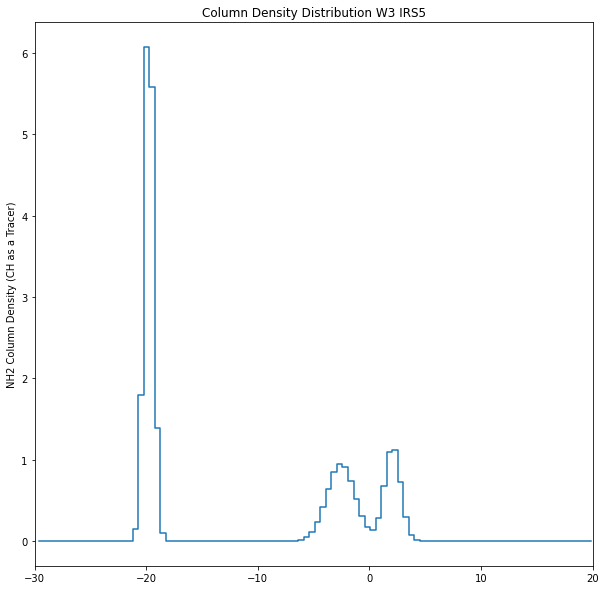

In [877]:
# Plot the Column Density Distribution:
fig, axs = plt.subplots(1, figsize=(10, 10))

axs.step(velnoh, noh/1e13)
axs.set_title('Column Density Distribution W3 IRS5')
axs.set_ylabel('NH2 Column Density (CH as a Tracer)')
axs.set_xlim([-30, 20])
#axs.set_ylim([0, 0.6e12])

In [878]:
# Number of gas components:
n = 1

# Figure of Merits:
aic = []
bic = []

# Add in intitial guesses
c0 = [-20.5]
s0 = [3]
aSof = [-0.5]
a1667 = [-0.05]
a1665 = [-0.015]
a1612 = [-0.015]
a1720 = [-0.015]

# Add in sigma guess from 18cm line:

# Instantiate fit parameters:
fit_params = Parameters()

# Set parameters:
makeVLA(n, dataVLA, fit_params, c0, a1667, a1665, a1612, a1720, s0)
makeSOFIA(n, dataSof, fit_params, c0, s0, aSof)

# Do the fitting
out = minimize(fcn=objective_n, params=fit_params, args=(n, vel67, VelSof, dataVLA, dataSof, tauSigmaRadio, tauSigmaSof), method='leastsq')
out

In [884]:
# We need the extent of the FWHM of the gaussians from the n(OH):
# FWHM = 2.355 * sigma.
# and the centers!

resultsTableW3 = pd.DataFrame(np.array([[0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0
                                         ]]),
                              columns = ['Source', 
                                         'Component', 
                                         'Line',
                                        'Peak',
                                        '\sigma Peak',
                                        'Center',
                                        '\sigma Center',
                                        'FWHM',
                                        '\sigma FWHM',
                                        'W',
                                        '\sigma W',
                                        'N(OH)',
                                        'Tex',
                                        '\sigma Tex'])

line = ['1667', '1665', '1612', '1720', '316', '298', '353']

for i in range(n):
    source = 'W3IRS5'
    comp = i
    for j in line:
        if j == '1667':
            l = 1
            
            # Get all values:
            Peak = out.params[f'amp{j}_{l}_{i}'].value
            sigPeak = out.params[f'amp{j}_{l}_{i}'].stderr
            Cen = out.params[f'cen{j}_{l}_{i}'].value
            sigCen = out.params[f'cen{j}_{l}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].stderr
            Wv = np.nan
            sigWv = np.nan
            
            igoodnoh = np.where((velnoh >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (velnoh <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(noh[igoodnoh])*delta
            
            k = 1
            Tex = -(0.45 * k * N_OH/1e14)/Peak
            sigTex = np.abs(Tex)*np.sqrt((sigPeak/Peak)**2)
        elif j == '1665':
            l = 2
            
            # Get all values:
            Peak = out.params[f'amp{j}_{l}_{i}'].value
            sigPeak = out.params[f'amp{j}_{l}_{i}'].stderr
            Cen = out.params[f'cen{j}_{l}_{i}'].value
            sigCen = out.params[f'cen{j}_{l}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].stderr
            Wv = np.nan
            sigWv = np.nan
            
            igoodnoh = np.where((velnoh >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (velnoh <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(noh[igoodnoh])*delta
            
            k = 5/9
            Tex = -(0.45 * k * N_OH/1e14)/Peak
            sigTex = np.abs(Tex)*np.sqrt((sigPeak/Peak)**2)
        elif j == '1612':
            l = 3
            
            # Get all values:
            Peak = out.params[f'amp{j}_{l}_{i}'].value
            sigPeak = out.params[f'amp{j}_{l}_{i}'].stderr
            Cen = out.params[f'cen{j}_{l}_{i}'].value
            sigCen = out.params[f'cen{j}_{l}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].stderr
            Wv = np.nan
            sigWv = np.nan
            
            igoodnoh = np.where((velnoh >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (velnoh <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(noh[igoodnoh])*delta
            
            k = 1/9
            Tex = -(0.45 * k * N_OH/1e14)/Peak
            sigTex = np.abs(Tex)*np.sqrt((sigPeak/Peak)**2)
        elif j == '1720':
            l = 4
            
            # Get all values:
            Peak = out.params[f'amp{j}_{l}_{i}'].value
            sigPeak = out.params[f'amp{j}_{l}_{i}'].stderr
            Cen = out.params[f'cen{j}_{l}_{i}'].value
            sigCen = out.params[f'cen{j}_{l}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].stderr
            Wv = np.nan
            sigWv = np.nan
            
            igoodnoh = np.where((velnoh >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (velnoh <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(noh[igoodnoh])*delta
            
            k = 1/9
            Tex = -(0.45 * k * N_OH/1e14)/Peak
            sigTex = np.abs(Tex)*np.sqrt((sigPeak/Peak)**2)
        elif j == '316':
            # Get all values:
            Peak = out.params[f'amp{j}_{i}'].value
            sigPeak = out.params[f'amp{j}_{i}'].stderr
            Cen = out.params[f'cen{j}_{i}'].value
            sigCen = out.params[f'cen{j}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{i}'].stderr
            Wv = np.nan
            sigWv = np.nan
            
            igoodnoh = np.where((velnoh >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (velnoh <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(noh[igoodnoh])*delta
            
            Tex = np.nan
            sigTex = np.nan
        elif j == '298':
            # Get all values:
            Peak = out.params[f'amp{j}_{i}'].value
            sigPeak = out.params[f'amp{j}_{i}'].stderr
            Cen = out.params[f'cen{j}_{i}'].value
            sigCen = out.params[f'cen{j}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{i}'].stderr
            Wv = np.nan
            sigWv = np.nan
            
            igoodnoh = np.where((velnoh >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (velnoh <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(noh[igoodnoh])*delta
            
            Tex = np.nan
            sigTex = np.nan
        elif j == '353':
            # Get all values:
            Peak = out.params[f'amp{j}_{i}'].value
            sigPeak = out.params[f'amp{j}_{i}'].stderr
            Cen = out.params[f'cen{j}_{i}'].value
            sigCen = out.params[f'cen{j}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{i}'].stderr
            Wv = np.nan
            sigWv = np.nan
            
            igoodnoh = np.where((velnoh >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (velnoh <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(noh[igoodnoh])*delta
            
            Tex = np.nan
            sigTex = np.nan
        
        resultsTableW3.loc[len(resultsTableW3.index)] = source, i, j, Peak, sigPeak, Cen, sigCen, fwhm, sigfwhm, Wv, sigWv, N_OH, Tex, sigTex

# Drop the first element:        
resultsTableW3 = resultsTableW3.drop(0)

In [885]:
resultsTableW3

,Source,Component,Line,Peak,\sigma Peak,Center,\sigma Center,FWHM,\sigma FWHM,W,\sigma W,N(OH),Tex,\sigma Tex
1,W3IRS5,0,1667,-0.086951,6.029922,-20.890748,0.035578,0.966917,0.083286,NaN,NaN,3.968008e+13,2.053583,142.413479
2,W3IRS5,0,1665,-0.053544,6.029971,-20.890748,0.035578,0.966917,0.083286,NaN,NaN,3.968008e+13,1.852685,208.644076
3,W3IRS5,0,1612,-0.005867,6.030240,-20.890748,0.035578,0.966917,0.083286,NaN,NaN,3.968008e+13,3.381513,3475.474794
4,W3IRS5,0,1720,-0.016164,6.030240,-20.890748,0.035578,0.966917,0.083286,NaN,NaN,3.968008e+13,1.227387,457.883202
5,W3IRS5,0,316,-0.671096,0.050183,-20.890748,0.035578,0.966917,0.083286,NaN,NaN,3.968008e+13,NaN,NaN
6,W3IRS5,0,298,-0.047648,0.003563,-18.820748,0.035578,0.966917,0.083286,NaN,NaN,3.497505e+13,NaN,NaN
7,W3IRS5,0,353,-0.429502,0.032117,-25.290748,0.035578,0.966917,0.083286,NaN,NaN,2.499279e+07,NaN,NaN


In [888]:
# Get the best fit for plotting the combined fits:
y_fitsof = gauss_dataset_sof_n(out.params, n, VelSof)
y_fit67 = gauss_dataset_n(out.params, n, 0, vel67)
y_fit65 = gauss_dataset_n(out.params, n, 1, vel65)
y_fit12 = gauss_dataset_n(out.params, n, 2, vel12)
y_fit20 = gauss_dataset_n(out.params, n, 3, vel20)

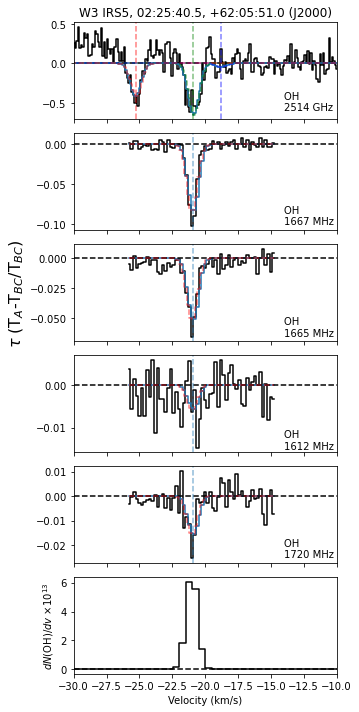

In [889]:
# What is the main beam efficiency for L-band VLA?
# 1 component


# Plot the data:
fig, axs = plt.subplots(6, figsize=(5, 10), sharex='all')

# Plot the OH:
axs[0].step(VelSof, (TaSof/7.8), 'k', label='OH 2.5 THz', where='mid')
axs[0].axhline(0, color='k', ls='dashed')
axs[0].step(VelSof, y_fitsof, where='mid')
axs[0].annotate('OH \n2514 GHz', xy=[-14,-0.6])
for i in range(n):
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='316', x=VelSof), alpha=0.5, ls='dashed', color='green')
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='298', x=VelSof), alpha=0.5, ls='dashed', color='blue')
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='353', x=VelSof), alpha=0.5, ls='dashed', color='red')
    axs[0].axvline(out.params[f'cen316_{i}'].value, ls='dashed', alpha=0.5, color='green')
    axs[0].axvline(out.params[f'cen298_{i}'].value, ls='dashed', alpha=0.5, color='blue')
    axs[0].axvline(out.params[f'cen353_{i}'].value, ls='dashed', alpha=0.5, color='red')

axs[1].step(vel67, (Ta67-Tc67)/Tc67, 'k', label='OH 1667 MHz', where='mid')
axs[1].step(vel67, y_fit67, where='mid')
axs[1].axhline(0, color='k', ls='dashed')
axs[1].annotate('OH \n1667 MHz', xy=[-14,-0.1])
for i in range(n):
    axs[1].step(vel67, gauss_dataset_VLA(out.params, i, 0 , x=vel67), alpha=0.5, ls='dashed', color='red')
    axs[1].axvline(out.params[f'cen1667_1_{i}'].value, ls='dashed', alpha=0.5)

axs[2].step(vel65, (Ta65-Tc65)/Tc65, 'k', label='OH 1665 MHz', where='mid')
axs[2].step(vel65, y_fit65, where='mid')
axs[2].axhline(0, color='k', ls='dashed')
axs[2].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[2].annotate('OH \n1665 MHz', xy=[-14,-0.065])
for i in range(n):
    axs[2].step(vel65, gauss_dataset_VLA(out.params, i, 1 , x=vel65), alpha=0.5, ls='dashed', color='red')
    axs[2].axvline(out.params[f'cen1665_2_{i}'].value, ls='dashed', alpha=0.5)

axs[3].step(vel12, (Ta12-Tc12)/Tc12, 'k', label='OH 1612 MHz', where='mid')
axs[3].step(vel12, y_fit12, where='mid')
axs[3].axhline(0, color='k', ls='dashed')
axs[3].annotate('OH \n1612 MHz', xy=[-14,-0.015])
for i in range(n):
    axs[3].step(vel12, gauss_dataset_VLA(out.params, i, 2 , x=vel12), alpha=0.5, ls='dashed', color='red')
    axs[3].axvline(out.params[f'cen1612_3_{i}'].value, ls='dashed', alpha=0.5)

axs[4].step(vel20, (Ta20-Tc20)/Tc20, 'k', label='OH 1720 MHz', where='mid')
axs[4].step(vel20, y_fit20, where='mid')
axs[4].axhline(0, color='k', ls='dashed')
axs[4].annotate('OH \n1720 MHz', xy=[-14,-0.025])
for i in range(n):
    axs[4].step(vel20, gauss_dataset_VLA(out.params, i, 3 , x=vel20), alpha=0.5, ls='dashed', color='red')
    axs[4].axvline(out.params[f'cen1720_4_{i}'].value, ls='dashed', alpha=0.5)

axs[5].step(velnoh-1, noh/1e13, 'k', where='mid')
axs[5].axhline(0, color='k', ls='dashed')
axs[5].set_ylabel(r'$dN(\mathrm{OH})/dv$ $\times 10^{13}$')

axs[5].set_xlim([-30, -10])

plt.xlabel('Velocity (km/s)')
axs[0].set_title('W3 IRS5, 02:25:40.5, +62:05:51.0 (J2000)')

fig.tight_layout()
fig.savefig("W3IRS5_1components.pdf", format='pdf', dpi=400)
fig.savefig("W3IRS5_1components.png", format='png', dpi=400)

In [890]:
# Loading up DR21:

# Load OH spectra toward DR21:

# Attempt to loading the SOFIA data:
#ohsof = ascii.read('ASCII_data_files/ASCII_data_files/W51E4_OH_2Pi32_velo.txt', format='csv', delimiter=' ', data_start=0, names=["Velo", "Tb"])
ohsof = ascii.read('ASCII_data_files/DR21/ASCII files/DR21_OH.spec', format='csv', delimiter=' ', data_start=4, names=["Velo", "Tb"])
dr21noh = ascii.read('Column_density_distributions/OH_For_Michael_Busch/column_density_files/Noh_DR21.txt')

# Sofia spectrum is in Tmb
TaSof = ohsof["Tb"]
VelSof = ohsof["Velo"]

# Velocity Bounds being set:
up = -10
low = 20

igood = np.where((VelSof >= up) & (VelSof <= low))

TaSof = ohsof["Tb"][igood]
VelSof = ohsof["Velo"][igood]

# For G10.47:
oh67 = ascii.read("VLAdata/VLASpectra/DR21/HYGAL_DR21_oh3_niter10000_threshold100mJybeam_highres_cube.30arcsec.image.pbcor.fits-Z-profile-Region_3-Statistic_Mean-Coordinate_Current-2023-12-11-00-17-26.tsv", format='tab', names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)
oh65 = ascii.read("VLAdata/VLASpectra/DR21/HYGAL_DR21_oh2_niter10000_threshold100mJybeam_highres_cube.30arcsec.image.pbcor.fits-Z-profile-Region_3-Statistic_Mean-Coordinate_Current-2023-12-11-00-17-26.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)
oh12 = ascii.read("VLAdata/VLASpectra/DR21/HYGAL_DR21_oh1_niter100000_threshold100mJybeam_highres_cube.30arcsec.image.pbcor.fits-Z-profile-Region_3-Statistic_Mean-Coordinate_Current-2023-12-11-00-17-26.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)
oh20 = ascii.read("VLAdata/VLASpectra/DR21/HYGAL_DR21_oh4_niter10000_threshold100mJybeam_highres_cube.30arcsec.image.pbcor.fits-Z-profile-Region_3-Statistic_Mean-Coordinate_Current-2023-12-11-00-17-26.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)

vel67 = oh67['VELO (km/s)']
Ta67 = oh67['Ta (K)']
vel65 = oh65['VELO (km/s)']
Ta65 = oh65['Ta (K)']
vel12 = oh12['VELO (km/s)']
Ta12 = oh12['Ta (K)']
vel20 = oh20['VELO (km/s)']
Ta20 = oh20['Ta (K)']
# Check this velocity shift with Arshia:
velnoh = dr21noh['col1']
noh = dr21noh['col2']

# Choose velocity range.
igood67 = np.where((vel67 >= up) & (vel67 <= low))
igood65 = np.where((vel65 >= up) & (vel65 <= low))
igood12 = np.where((vel12 >= up) & (vel12 <= low))
igood20 = np.where((vel20 >= up) & (vel20 <= low))
igoodnoh = np.where((velnoh >= up) & (velnoh <= low))

# Choose a continuum.
igood67c = np.where((vel67 >= up) & (vel67 <= low))
igood65c = np.where((vel65 >= up) & (vel65 <= low))
igood12c = np.where((vel12 >= up) & (vel12 <= low))
igood20c = np.where((vel20 >= up) & (vel20 <= low))
igoodSofc = np.where((VelSof >= -18) & (VelSof <= 20))

# Calculate median continuum temperature:
Tc67 = np.median(Ta67[igood67c])
Tc65 = np.median(Ta65[igood65c])
Tc12 = np.median(Ta12[igood12c])
Tc20 = np.median(Ta20[igood20c])

# Limit velocity range:
vel67 = vel67[igood67]
Ta67 = Ta67[igood67]
vel65 = vel65[igood65]
Ta65 = Ta65[igood65]
vel12 = vel12[igood12]
Ta12 = Ta12[igood12]
vel20 = vel20[igood20]
Ta20 = Ta20[igood20]
#velnoh = velnoh[igoodnoh]
#noh = noh[igoodnoh]

#igoodnoh = np.where((velnoh >= 0) & (velnoh <= 10))
#delta = abs(velnoh[1]-velnoh[0])
#columnDensity = np.sum(dn_OH_tot)*delta*u.cm**-2

Text(0.5, 1.0, 'DR21, 20:39:01,6, +42:19:37.9 (J2000)')

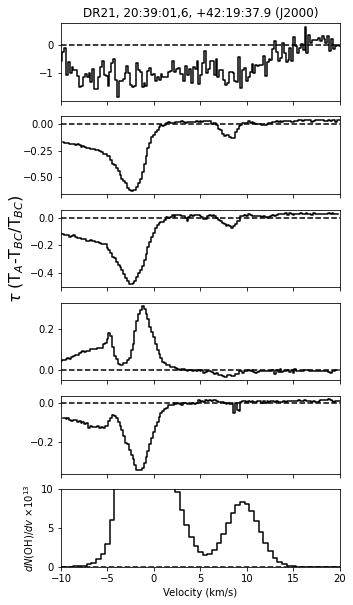

In [684]:
# What is the main beam efficiency for L-band VLA?
# Plot the data:
fig, axs = plt.subplots(6, figsize=(5, 10), sharex='all')

# Plot the OH:
axs[0].step(VelSof, ((TaSof-2.69)/2.69), 'k', label='OH 2.5 THz', where='mid')
axs[0].axhline(0, color='k', ls='dashed')
axs[0].annotate('OH \n2514 GHz', xy=[50,-0.6])

axs[1].step(vel67, (Ta67-Tc67)/Tc67, 'k', label='OH 1667 MHz', where='mid')
axs[1].axhline(0, color='k', ls='dashed')
axs[1].annotate('OH \n1667 MHz', xy=[50,-0.1])

axs[2].step(vel65, (Ta65-Tc65)/Tc65, 'k', label='OH 1665 MHz', where='mid')
axs[2].axhline(0, color='k', ls='dashed')
axs[2].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[2].annotate('OH \n1665 MHz', xy=[50,-0.065])

axs[3].step(vel12, (Ta12-Tc12)/Tc12, 'k', label='OH 1612 MHz', where='mid')
axs[3].axhline(0, color='k', ls='dashed')
axs[3].annotate('OH \n1612 MHz', xy=[50,-0.015])

axs[4].step(vel20, (Ta20-Tc20)/Tc20, 'k', label='OH 1720 MHz', where='mid')
axs[4].axhline(0, color='k', ls='dashed')
axs[4].annotate('OH \n1720 MHz', xy=[50,-0.025])

axs[5].step(velnoh, noh/1e13, 'k', where='mid')
axs[5].axhline(0, color='k', ls='dashed')
axs[5].set_ylim([0, 10])
axs[5].set_ylabel(r'$dN(\mathrm{OH})/dv$ $\times 10^{13}$')

axs[5].set_xlim([up, low])

plt.xlabel('Velocity (km/s)')
axs[0].set_title('DR21, 20:39:01,6, +42:19:37.9 (J2000)')

In [105]:
# Possibly optically thick at 8 km/s?

In [891]:
# Load up G29.96:

# Attempt to loading the SOFIA data:
#ohsof = ascii.read('ASCII_data_files/ASCII_data_files/W51E4_OH_2Pi32_velo.txt', format='csv', delimiter=' ', data_start=0, names=["Velo", "Tb"])
ohsof = ascii.read('ASCII_data_files/G29.96-0.02/ASCII files/G29P96_OH.spec', format='csv', delimiter=' ', data_start=4, names=["Velo", "Tb"])
g29noh = ascii.read('Column_density_distributions/OH_For_Michael_Busch/column_density_files/Noh_G29P96.txt')

# Sofia spectrum is in Tmb
TaSof = ohsof["Tb"]
VelSof = ohsof["Velo"]

# Velocity Bounds being set:
up = -10
low = 30

igood = np.where((VelSof >= up) & (VelSof <= low))

TaSof = ohsof["Tb"][igood]
VelSof = ohsof["Velo"][igood]

# For G10.47:
oh67 = ascii.read("VLAdata/VLASpectra/G29.96/HYGAL_G29p96-0p02_oh3_niter10000_threshold100mJybeam_highres_cube.20arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2023-12-11-00-27-23.tsv", format='tab', names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)
oh65 = ascii.read("VLAdata/VLASpectra/G29.96/HYGAL_G29p96-0p02_oh2_niter10000_threshold100mJybeam_highres_cube.20arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2023-12-11-00-27-23.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)
oh12 = ascii.read("VLAdata/VLASpectra/G29.96/HYGAL_G29p96-0p02_oh1_niter100000_threshold100mJybeam_highres_cube.20arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2023-12-11-00-27-23.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)
oh20 = ascii.read("VLAdata/VLASpectra/G29.96/HYGAL_G29p96-0p02_oh4_niter10000_threshold100mJybeam_highres_cube.20arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2023-12-11-00-27-23.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)

vel67 = oh67['VELO (km/s)']
Ta67 = oh67['Ta (K)']
vel65 = oh65['VELO (km/s)']
Ta65 = oh65['Ta (K)']
vel12 = oh12['VELO (km/s)']
Ta12 = oh12['Ta (K)']
vel20 = oh20['VELO (km/s)']
Ta20 = oh20['Ta (K)']
# Check this velocity shift with Arshia:
velnoh = g29noh['col1']
noh = g29noh['col2']

# Choose velocity range.
igood67 = np.where((vel67 >= up) & (vel67 <= low))
igood65 = np.where((vel65 >= up) & (vel65 <= low))
igood12 = np.where((vel12 >= up) & (vel12 <= low))
igood20 = np.where((vel20 >= up) & (vel20 <= low))
igoodnoh = np.where((velnoh >= up) & (velnoh <= low))

# Choose a continuum.
igood67c = np.where((vel67 >= 15) & (vel67 <= 25))
igood65c = np.where((vel65 >= 15) & (vel65 <= 25))
igood12c = np.where((vel12 >= 15) & (vel12 <= 25))
igood20c = np.where((vel20 >= 15) & (vel20 <= 25))
igoodSofc = np.where((VelSof >= 15) & (VelSof <= 25))

# Calculate standard deviation of Tau for VLA:
tauSigmaRadio = (Ta67-Tc67)/Tc67
tauSigmaRadio = np.std(tauSigmaRadio[igood67c])

# Calculate standard deviation of Tau for SOFIA:
tauSigmaSof = (TaSof/5.15)
tauSigmaSof = np.std(tauSigmaSof[igoodSofc])

# Calculate median continuum temperature:
Tc67 = np.median(Ta67[igood67c])
Tc65 = np.median(Ta65[igood65c])
Tc12 = np.median(Ta12[igood12c])
Tc20 = np.median(Ta20[igood20c])

# Limit velocity range:
vel67 = vel67[igood67]
Ta67 = Ta67[igood67]
vel65 = vel65[igood65]
Ta65 = Ta65[igood65]
vel12 = vel12[igood12]
Ta12 = Ta12[igood12]
vel20 = vel20[igood20]
Ta20 = Ta20[igood20]
velnoh = velnoh[igoodnoh]
noh = noh[igoodnoh]

igoodnoh = np.where((velnoh >= 0) & (velnoh <= 10))
delta = abs(velnoh[1]-velnoh[0])
columnDensity = np.sum(dn_OH_tot)*delta*u.cm**-2

In [892]:
# Fit the W51 data with a single component Gaussian for each line:
# Create two data arrays, one for VLA and one for Sofia:
dataVLA = [((Ta67-Tc67)/Tc67).value, ((Ta65-Tc65)/Tc65).value, ((Ta12-Tc12)/Tc12).value, ((Ta20-Tc20)/Tc20).value]
dataVLA = np.array(dataVLA)

dataSof = [((TaSof-5.15)/5.15)]
dataSof = np.array(dataSof)

In [893]:
# Fitting G29 using 2 components:

# Number of gas components:
n = 1

# Figure of Merits:
aic = []
bic = []

# Add in intitial guesses
c0 = [5]
s0 = [2]
aSof = [-0.5]
a1667 = [-0.1]
a1665 = [-0.05]
a1612 = [-0.03]
a1720 = [-0.01]

# Add in sigma guess from 18cm line:

# Instantiate fit parameters:
fit_params = Parameters()

# Set parameters:
makeVLA(n, dataVLA, fit_params, c0, a1667, a1665, a1612, a1720, s0, lim=3)
makeSOFIA(n, dataSof, fit_params, c0, s0, aSof)

# Do the fitting
out = minimize(fcn=objective_n, params=fit_params, args=(n, vel67, VelSof, dataVLA, dataSof, tauSigmaRadio, tauSigmaSof), method='leastsq')
out

In [895]:
# We need the extent of the FWHM of the gaussians from the n(OH):
# FWHM = 2.355 * sigma.
# and the centers!

resultsTableG29 = pd.DataFrame(np.array([[0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0
                                         ]]),
                              columns = ['Source', 
                                         'Component', 
                                         'Line',
                                        'Peak',
                                        '\sigma Peak',
                                        'Center',
                                        '\sigma Center',
                                        'FWHM',
                                        '\sigma FWHM',
                                        'W',
                                        '\sigma W',
                                        'N(OH)',
                                        'Tex',
                                        '\sigma Tex'])

line = ['1667', '1665', '1612', '1720', '316', '298', '353']

for i in range(n):
    source = 'G29'
    comp = i
    for j in line:
        if j == '1667':
            l = 1
            
            # Get all values:
            Peak = out.params[f'amp{j}_{l}_{i}'].value
            sigPeak = out.params[f'amp{j}_{l}_{i}'].stderr
            Cen = out.params[f'cen{j}_{l}_{i}'].value
            sigCen = out.params[f'cen{j}_{l}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].stderr
            Wv = np.nan
            sigWv = np.nan
            
            igoodnoh = np.where((velnoh >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (velnoh <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(noh[igoodnoh])*delta
            
            k = 1
            Tex = -(0.45 * k * N_OH/1e14)/Peak
            sigTex = np.abs(Tex)*np.sqrt((sigPeak/Peak)**2)
        elif j == '1665':
            l = 2
            
            # Get all values:
            Peak = out.params[f'amp{j}_{l}_{i}'].value
            sigPeak = out.params[f'amp{j}_{l}_{i}'].stderr
            Cen = out.params[f'cen{j}_{l}_{i}'].value
            sigCen = out.params[f'cen{j}_{l}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].stderr
            Wv = np.nan
            sigWv = np.nan
            
            igoodnoh = np.where((velnoh >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (velnoh <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(noh[igoodnoh])*delta
            
            k = 5/9
            Tex = -(0.45 * k * N_OH/1e14)/Peak
            sigTex = np.abs(Tex)*np.sqrt((sigPeak/Peak)**2)
        elif j == '1612':
            l = 3
            
            # Get all values:
            Peak = out.params[f'amp{j}_{l}_{i}'].value
            sigPeak = out.params[f'amp{j}_{l}_{i}'].stderr
            Cen = out.params[f'cen{j}_{l}_{i}'].value
            sigCen = out.params[f'cen{j}_{l}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].stderr
            Wv = np.nan
            sigWv = np.nan
            
            igoodnoh = np.where((velnoh >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (velnoh <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(noh[igoodnoh])*delta
            
            k = 1/9
            Tex = -(0.45 * k * N_OH/1e14)/Peak
            sigTex = np.abs(Tex)*np.sqrt((sigPeak/Peak)**2)
        elif j == '1720':
            l = 4
            
            # Get all values:
            Peak = out.params[f'amp{j}_{l}_{i}'].value
            sigPeak = out.params[f'amp{j}_{l}_{i}'].stderr
            Cen = out.params[f'cen{j}_{l}_{i}'].value
            sigCen = out.params[f'cen{j}_{l}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].stderr
            Wv = np.nan
            sigWv = np.nan
            
            igoodnoh = np.where((velnoh >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (velnoh <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(noh[igoodnoh])*delta
            
            k = 1/9
            Tex = -(0.45 * k * N_OH/1e14)/Peak
            sigTex = np.abs(Tex)*np.sqrt((sigPeak/Peak)**2)
            
        elif j == '316':
            # Get all values:
            Peak = out.params[f'amp{j}_{i}'].value
            sigPeak = out.params[f'amp{j}_{i}'].stderr
            Cen = out.params[f'cen{j}_{i}'].value
            sigCen = out.params[f'cen{j}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{i}'].stderr
            Wv = np.nan
            sigWv = np.nan
            
            igoodnoh = np.where((velnoh >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (velnoh <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(noh[igoodnoh])*delta
            
            Tex = np.nan
            sigTex = np.nan
        elif j == '298':
            # Get all values:
            Peak = out.params[f'amp{j}_{i}'].value
            sigPeak = out.params[f'amp{j}_{i}'].stderr
            Cen = out.params[f'cen{j}_{i}'].value
            sigCen = out.params[f'cen{j}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{i}'].stderr
            Wv = np.nan
            sigWv = np.nan
            
            igoodnoh = np.where((velnoh >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (velnoh <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(noh[igoodnoh])*delta
            
            Tex = np.nan
            sigTex = np.nan
        elif j == '353':
            # Get all values:
            Peak = out.params[f'amp{j}_{i}'].value
            sigPeak = out.params[f'amp{j}_{i}'].stderr
            Cen = out.params[f'cen{j}_{i}'].value
            sigCen = out.params[f'cen{j}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{i}'].stderr
            Wv = np.nan
            sigWv = np.nan
            
            igoodnoh = np.where((velnoh >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (velnoh <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(noh[igoodnoh])*delta
            
            Tex = np.nan
            sigTex = np.nan
        
        resultsTableG29.loc[len(resultsTableG29.index)] = source, i, j, Peak, sigPeak, Cen, sigCen, fwhm, sigfwhm, Wv, sigWv, N_OH, Tex, sigTex

# Drop the first element:        
resultsTableG29 = resultsTableG29.drop(0)

In [896]:
resultsTableG29

,Source,Component,Line,Peak,\sigma Peak,Center,\sigma Center,FWHM,\sigma FWHM,W,\sigma W,N(OH),Tex,\sigma Tex
1,G29,0,1667,-0.255331,0.012153,7.537369,0.051635,2.690654,0.12134,NaN,NaN,1.556438e+14,2.743095,0.130561
2,G29,0,1665,-0.156538,0.011270,7.537369,0.051635,2.690654,0.12134,NaN,NaN,1.556438e+14,2.485721,0.178953
3,G29,0,1612,-0.130161,0.011098,7.537369,0.051635,2.690654,0.12134,NaN,NaN,1.556438e+14,0.597889,0.050977
4,G29,0,1720,0.067132,0.010809,7.537369,0.051635,2.690654,0.12134,NaN,NaN,1.556438e+14,-1.159242,0.186654
5,G29,0,316,-1.500000,1.875565,7.537369,0.051635,2.690654,0.12134,NaN,NaN,1.556438e+14,NaN,NaN
6,G29,0,298,-0.106500,0.133165,9.607369,0.051635,2.690654,0.12134,NaN,NaN,1.237197e+14,NaN,NaN
7,G29,0,353,-0.960000,1.200362,3.137369,0.051635,2.690654,0.12134,NaN,NaN,3.927145e+13,NaN,NaN


In [897]:
# Get the best fit for plotting the combined fits:
y_fitsof = gauss_dataset_sof_n(out.params, n, VelSof)
y_fit67 = gauss_dataset_n(out.params, n, 0, vel67)
y_fit65 = gauss_dataset_n(out.params, n, 1, vel65)
y_fit12 = gauss_dataset_n(out.params, n, 2, vel12)
y_fit20 = gauss_dataset_n(out.params, n, 3, vel20)

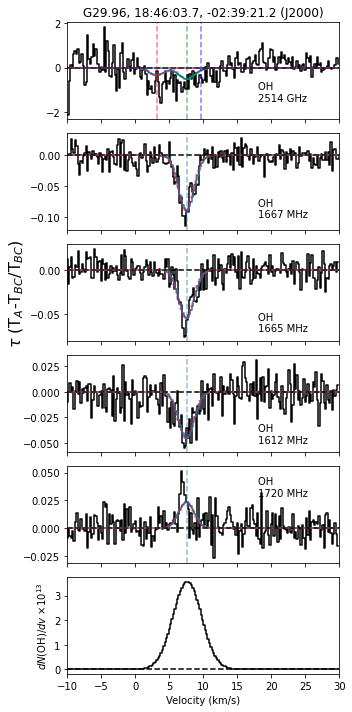

In [898]:
# What is the main beam efficiency for L-band VLA?
# 3 components

# Plot the data:
fig, axs = plt.subplots(6, figsize=(5, 10), sharex='all')

# Plot the OH:
axs[0].step(VelSof, ((TaSof-5.15)/5.15), 'k', label='OH 2.5 THz', where='mid')
axs[0].step(VelSof, y_fitsof, where='mid')
axs[0].axhline(0, color='k', ls='dashed')
axs[0].annotate('OH \n2514 GHz', xy=[18,-1.5])
for i in range(n):
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='316', x=VelSof), alpha=0.5, ls='dashed', color='green')
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='298', x=VelSof), alpha=0.5, ls='dashed', color='blue')
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='353', x=VelSof), alpha=0.5, ls='dashed', color='red')
    axs[0].axvline(out.params[f'cen316_{i}'].value, ls='dashed', alpha=0.5, color='green')
    axs[0].axvline(out.params[f'cen298_{i}'].value, ls='dashed', alpha=0.5, color='blue')
    axs[0].axvline(out.params[f'cen353_{i}'].value, ls='dashed', alpha=0.5, color='red')

axs[1].step(vel67, (Ta67-Tc67)/Tc67, 'k', label='OH 1667 MHz', where='mid')
axs[1].step(vel67, y_fit67, where='mid')
axs[1].axhline(0, color='k', ls='dashed')
axs[1].annotate('OH \n1667 MHz', xy=[18,-0.1])
for i in range(n):
    axs[1].step(vel67, gauss_dataset_VLA(out.params, i, 0 , x=vel67), alpha=0.5, ls='dashed', color='red')
    axs[1].axvline(out.params[f'cen1667_1_{i}'].value, ls='dashed', alpha=0.5)

axs[2].step(vel65, (Ta65-Tc65)/Tc65, 'k', label='OH 1665 MHz', where='mid')
axs[2].step(vel65, y_fit65, where='mid')
axs[2].axhline(0, color='k', ls='dashed')
axs[2].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[2].annotate('OH \n1665 MHz', xy=[18,-0.07])
for i in range(n):
    axs[2].step(vel65, gauss_dataset_VLA(out.params, i, 1 , x=vel65), alpha=0.5, ls='dashed', color='red')
    axs[2].axvline(out.params[f'cen1665_2_{i}'].value, ls='dashed', alpha=0.5)

axs[3].step(vel12, (Ta12-Tc12)/Tc12, 'k', label='OH 1612 MHz', where='mid')
axs[3].step(vel12, y_fit12, where='mid')
axs[3].axhline(0, color='k', ls='dashed')
axs[3].annotate('OH \n1612 MHz', xy=[18,-0.05])
for i in range(n):
    axs[3].step(vel12, gauss_dataset_VLA(out.params, i, 2 , x=vel12), alpha=0.5, ls='dashed', color='red')
    axs[3].axvline(out.params[f'cen1612_3_{i}'].value, ls='dashed', alpha=0.5)

axs[4].step(vel20, (Ta20-Tc20)/Tc20, 'k', label='OH 1720 MHz', where='mid')
axs[4].step(vel20, y_fit20, where='mid')
axs[4].axhline(0, color='k', ls='dashed')
axs[4].annotate('OH \n1720 MHz', xy=[18,0.029])
for i in range(n):
    axs[4].step(vel20, gauss_dataset_VLA(out.params, i, 3 , x=vel20), alpha=0.5, ls='dashed', color='red')
    axs[4].axvline(out.params[f'cen1720_4_{i}'].value, ls='dashed', alpha=0.5)

axs[5].step(velnoh, noh/1e13, 'k', where='mid')
axs[5].axhline(0, color='k', ls='dashed')
#axs[5].annotate('TBD', xy=[10,0.5])
axs[5].set_ylabel(r'$dN(\mathrm{OH})/dv$ $\times 10^{13}$')

axs[5].set_xlim([up, low])

plt.xlabel('Velocity (km/s)')
axs[0].set_title('G29.96, 18:46:03.7, -02:39:21.2 (J2000)')

fig.tight_layout()
fig.savefig("G29_2components.pdf", format='pdf', dpi=400)
fig.savefig("G29_2components.png", format='png', dpi=400)

In [738]:
# Load up G32.80:

# Attempt to loading the SOFIA data:
#ohsof = ascii.read('ASCII_data_files/ASCII_data_files/W51E4_OH_2Pi32_velo.txt', format='csv', delimiter=' ', data_start=0, names=["Velo", "Tb"])
ohsof = ascii.read('ASCII_data_files/G32.80+0.19/ASCII files/G32P80_OH.spec', format='csv', delimiter=' ', data_start=4, names=["Velo", "Tb"])
g32noh = ascii.read('Column_density_distributions/OH_For_Michael_Busch/column_density_files/Noh_G32P80.txt')

# Sofia spectrum is in Tmb
TaSof = ohsof["Tb"]
VelSof = ohsof["Velo"]

# Velocity Bounds being set:
up = 60
low = 120

igood = np.where((VelSof >= up) & (VelSof <= low))

TaSof = ohsof["Tb"][igood]
VelSof = ohsof["Velo"][igood]

# For G10.47:
oh67 = ascii.read("VLAdata/VLASpectra/G32.80/HYGAL_G32p80+0p19_oh3_niter10000_threshold100mJybeam_highres_cube.20arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2024-04-17-13-56-19.tsv", format='tab', names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9)
oh65 = ascii.read("VLAdata/VLASpectra/G32.80/HYGAL_G32p80+0p19_oh2_niter10000_threshold100mJybeam_highres_cube.20arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2024-04-17-13-56-19.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9)
oh12 = ascii.read("VLAdata/VLASpectra/G32.80/HYGAL_G32p80+0p19_oh1_niter100000_threshold100mJybeam_highres_cube.20arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2024-04-17-13-56-19.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9)
oh20 = ascii.read("VLAdata/VLASpectra/G32.80/HYGAL_G32p80+0p19_oh4_niter10000_threshold100mJybeam_highres_cube.20arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2024-04-17-13-56-19.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9)

vel67 = oh67['VELO (km/s)']
Ta67 = oh67['Ta (K)']
vel65 = oh65['VELO (km/s)']
Ta65 = oh65['Ta (K)']
vel12 = oh12['VELO (km/s)']
Ta12 = oh12['Ta (K)']
vel20 = oh20['VELO (km/s)']
Ta20 = oh20['Ta (K)']
# Check this velocity shift with Arshia:
velnoh = g32noh['col1']
noh = g32noh['col2']

# Choose velocity range.
igood67 = np.where((vel67 >= up) & (vel67 <= low))
igood65 = np.where((vel65 >= up) & (vel65 <= low))
igood12 = np.where((vel12 >= up) & (vel12 <= low))
igood20 = np.where((vel20 >= up) & (vel20 <= low))
igoodnoh = np.where((velnoh >= up) & (velnoh <= low))

# Choose a continuum.
igood67c = np.where((vel67 >= up) & (vel67 <= low))
igood65c = np.where((vel65 >= up) & (vel65 <= low))
igood12c = np.where((vel12 >= up) & (vel12 <= low))
igood20c = np.where((vel20 >= up) & (vel20 <= low))

# Calculate standard deviation of Tau for VLA:
tauSigmaRadio = (Ta67-Tc67)/Tc67
tauSigmaRadio = np.std(tauSigmaRadio[igood67c])

# Calculate standard deviation of Tau for SOFIA:
tauSigmaSof = (TaSof/4.05)
tauSigmaSof = np.std(tauSigmaSof[igoodSofc])

# Calculate median continuum temperature:
Tc67 = np.median(Ta67[igood67c])
Tc65 = np.median(Ta65[igood65c])
Tc12 = np.median(Ta12[igood12c])
Tc20 = np.median(Ta20[igood20c])

# Limit velocity range:
vel67 = vel67[igood67]
Ta67 = Ta67[igood67]
vel65 = vel65[igood65]
Ta65 = Ta65[igood65]
vel12 = vel12[igood12]
Ta12 = Ta12[igood12]
vel20 = vel20[igood20]
Ta20 = Ta20[igood20]
velnoh = velnoh[igoodnoh]
noh = noh[igoodnoh]

In [739]:
delta

0.20383310999999793

In [740]:
# Fit the W51 data with a single component Gaussian for each line:
# Create two data arrays, one for VLA and one for Sofia:
dataVLA = [((Ta67-Tc67)/Tc67).value, ((Ta65-Tc65)/Tc65).value, ((Ta12-Tc12)/Tc12).value, ((Ta20-Tc20)/Tc20).value]
dataVLA = np.array(dataVLA)

dataSof = [((TaSof-4.05)/4.05)]
dataSof = np.array(dataSof)

In [779]:
# Fitting G32 using 5 components:

# Number of gas components:
n = 5

# Figure of Merits:
aic = []
bic = []

# Add in intitial guesses
c0 = [70, 80, 85, 89, 91]
s0 = [1, 1, 1, 1, 1]
aSof = [-0.3, -0.3, -0.3, -0.3, -0.3]
a1667 = [-0.1, -0.1, -0.1, -0.1, -0.1]
a1665 = [-0.05, -0.05, -0.05, -0.05, -0.05]
a1612 = [-0.03, -0.03, -0.03, -0.03, -0.03]
a1720 = [0.03, 0.03, 0.03, 0.03, 0.03]

# Add in sigma guess from 18cm line:

# Instantiate fit parameters:
fit_params = Parameters()

# Set parameters:
makeVLA(n, dataVLA, fit_params, c0, a1667, a1665, a1612, a1720, s0, lim=3)
makeSOFIA(n, dataSof, fit_params, c0, s0, aSof)

# Do the fitting
out = minimize(fcn=objective_n, params=fit_params, args=(n, vel67, VelSof, dataVLA, dataSof, tauSigmaRadio, tauSigmaSof), method='leastsq')
out

In [780]:
# We need the extent of the FWHM of the gaussians from the n(OH):
# FWHM = 2.355 * sigma.
# and the centers!

resultsTableG32 = pd.DataFrame(np.array([[0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0
                                         ]]),
                              columns = ['Source', 
                                         'Component', 
                                         'Line',
                                        'Peak',
                                        '\sigma Peak',
                                        'Center',
                                        '\sigma Center',
                                        'FWHM',
                                        '\sigma FWHM',
                                        'W',
                                        '\sigma W',
                                        'N(OH)',
                                        'Tex',
                                        '\sigma Tex'])

line = ['1667', '1665', '1612', '1720', '316', '298', '353']

for i in range(n):
    source = 'G32'
    comp = i
    for j in line:
        if j == '1667':
            l = 1
            
            # Get all values:
            Peak = out.params[f'amp{j}_{l}_{i}'].value
            sigPeak = out.params[f'amp{j}_{l}_{i}'].stderr
            Cen = out.params[f'cen{j}_{l}_{i}'].value
            sigCen = out.params[f'cen{j}_{l}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].stderr
            Wv = out.params[f'W{j}_{l}_{i}'].value
            sigWv = out.params[f'W{j}_{l}_{i}'].stderr
            
            igoodnoh = np.where((velnoh >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (velnoh <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(noh[igoodnoh])*delta
            
            k = 1
            Tex = -(0.45 * k * N_OH/1e14)/Wv
            sigTex = np.abs(Tex)*np.sqrt((sigWv/Wv)**2)
        elif j == '1665':
            l = 2
            
            # Get all values:
            Peak = out.params[f'amp{j}_{l}_{i}'].value
            sigPeak = out.params[f'amp{j}_{l}_{i}'].stderr
            Cen = out.params[f'cen{j}_{l}_{i}'].value
            sigCen = out.params[f'cen{j}_{l}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].stderr
            Wv = out.params[f'W{j}_{l}_{i}'].value
            sigWv = out.params[f'W{j}_{l}_{i}'].stderr
            
            igoodnoh = np.where((velnoh >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (velnoh <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(noh[igoodnoh])*delta
            
            k = 5/9
            Tex = -(0.45 * k * N_OH/1e14)/Wv
            sigTex = np.abs(Tex)*np.sqrt((sigWv/Wv)**2)
        elif j == '1612':
            l = 3
            
            # Get all values:
            Peak = out.params[f'amp{j}_{l}_{i}'].value
            sigPeak = out.params[f'amp{j}_{l}_{i}'].stderr
            Cen = out.params[f'cen{j}_{l}_{i}'].value
            sigCen = out.params[f'cen{j}_{l}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].stderr
            Wv = out.params[f'W{j}_{l}_{i}'].value
            sigWv = out.params[f'W{j}_{l}_{i}'].stderr
            
            igoodnoh = np.where((velnoh >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (velnoh <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(noh[igoodnoh])*delta
            
            k = 1/9
            Tex = -(0.45 * k * N_OH/1e14)/Wv
            sigTex = np.abs(Tex)*np.sqrt((sigWv/Wv)**2)
        elif j == '1720':
            l = 4
            
            # Get all values:
            Peak = out.params[f'amp{j}_{l}_{i}'].value
            sigPeak = out.params[f'amp{j}_{l}_{i}'].stderr
            Cen = out.params[f'cen{j}_{l}_{i}'].value
            sigCen = out.params[f'cen{j}_{l}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].stderr
            Wv = out.params[f'W{j}_{l}_{i}'].value
            sigWv = out.params[f'W{j}_{l}_{i}'].stderr
            
            igoodnoh = np.where((velnoh >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (velnoh <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(noh[igoodnoh])*delta
            
            k = 1/9
            Tex = -(0.45 * k * N_OH/1e14)/Wv
            sigTex = np.abs(Tex)*np.sqrt((sigWv/Wv)**2)
            
        elif j == '316':
            # Get all values:
            Peak = out.params[f'amp{j}_{i}'].value
            sigPeak = out.params[f'amp{j}_{i}'].stderr
            Cen = out.params[f'cen{j}_{i}'].value
            sigCen = out.params[f'cen{j}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{i}'].stderr
            Wv = out.params[f'W{j}_{i}'].value
            sigWv = out.params[f'W{j}_{i}'].stderr
            
            igoodnoh = np.where((velnoh >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (velnoh <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(noh[igoodnoh])*delta
            
            Tex = np.nan
            sigTex = np.nan
        elif j == '298':
            # Get all values:
            Peak = out.params[f'amp{j}_{i}'].value
            sigPeak = out.params[f'amp{j}_{i}'].stderr
            Cen = out.params[f'cen{j}_{i}'].value
            sigCen = out.params[f'cen{j}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{i}'].stderr
            Wv = out.params[f'W{j}_{i}'].value
            sigWv = out.params[f'W{j}_{i}'].stderr
            
            igoodnoh = np.where((velnoh >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (velnoh <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(noh[igoodnoh])*delta
            
            Tex = np.nan
            sigTex = np.nan
        elif j == '353':
            # Get all values:
            Peak = out.params[f'amp{j}_{i}'].value
            sigPeak = out.params[f'amp{j}_{i}'].stderr
            Cen = out.params[f'cen{j}_{i}'].value
            sigCen = out.params[f'cen{j}_{i}'].stderr
            fwhm = 2.355*out.params[f'sig{j}_{i}'].value
            sigfwhm = 2.355*out.params[f'sig{j}_{i}'].stderr
            Wv = out.params[f'W{j}_{i}'].value
            sigWv = out.params[f'W{j}_{i}'].stderr
            
            igoodnoh = np.where((velnoh >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (velnoh <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
            N_OH = np.sum(noh[igoodnoh])*delta
            
            Tex = np.nan
            sigTex = np.nan
        
        resultsTableG32.loc[len(resultsTableG32.index)] = source, i, j, Peak, sigPeak, Cen, sigCen, fwhm, sigfwhm, Wv, sigWv, N_OH, Tex, sigTex

# Drop the first element:        
resultsTableG32 = resultsTableG32.drop(0)

In [781]:
resultsTableG32

,Source,Component,Line,Peak,\sigma Peak,Center,\sigma Center,FWHM,\sigma FWHM,W,\sigma W,N(OH),Tex,\sigma Tex
1,G32,0,1667,-0.005703,0.002732,71.841961,0.225459,8.255437,0.719100,-0.050112,0.024085,2.628913e+14,23.607433,11.346471
2,G32,0,1665,-0.004019,0.002727,71.841961,0.225459,8.255437,0.719100,-0.035314,0.023991,2.628913e+14,18.610941,12.643430
3,G32,0,1612,0.003481,0.002727,71.841961,0.225459,8.255437,0.719100,0.030593,0.023965,2.628913e+14,-4.296599,3.365686
4,G32,0,1720,-0.003330,0.002726,71.841961,0.225459,8.255437,0.719100,-0.029263,0.023967,2.628913e+14,4.491943,3.679006
5,G32,0,316,-0.597838,0.035251,71.841961,0.225459,8.255437,0.719100,-5.253584,0.255925,2.628913e+14,NaN,NaN
6,G32,0,298,-0.042446,0.002503,73.911961,0.225459,8.255437,0.719100,-0.373004,0.018171,3.638986e+14,NaN,NaN
7,G32,0,353,-0.382616,0.022561,67.441961,0.225459,8.255437,0.719100,-3.362294,0.163792,1.895858e+14,NaN,NaN
8,G32,1,1667,-0.049091,0.004501,81.345220,0.105443,3.328803,0.201149,-0.173950,0.016327,2.977492e+14,7.702605,0.722976
9,G32,1,1665,-0.019983,0.004329,81.345220,0.105443,3.328803,0.201149,-0.070808,0.015457,2.977492e+14,10.512613,2.294847
10,G32,1,1612,0.002104,0.004316,81.345220,0.105443,3.328803,0.201149,0.007457,0.015288,2.977492e+14,-19.964828,40.931580


In [782]:
# Get the best fit for plotting the combined fits:
y_fitsof = gauss_dataset_sof_n(out.params, n, VelSof)
y_fit67 = gauss_dataset_n(out.params, n, 0, vel67)
y_fit65 = gauss_dataset_n(out.params, n, 1, vel65)
y_fit12 = gauss_dataset_n(out.params, n, 2, vel12)
y_fit20 = gauss_dataset_n(out.params, n, 3, vel20)

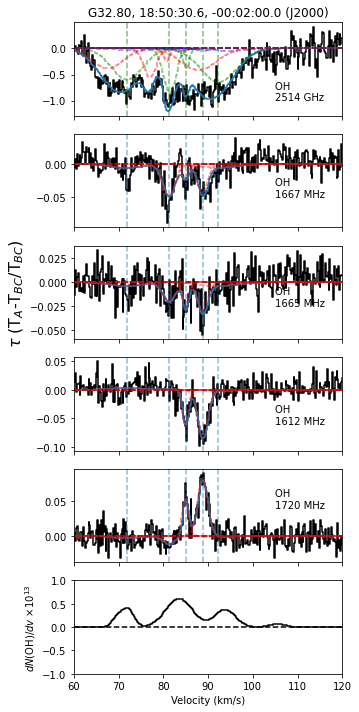

In [793]:
# What is the main beam efficiency for L-band VLA?
# 2 components

# Plot the data:
fig, axs = plt.subplots(6, figsize=(5, 10), sharex='all')

# Plot the OH:
axs[0].step(VelSof, ((TaSof-4.05)/4.05), 'k', label='OH 2.5 THz', where='mid')
axs[0].step(VelSof, y_fitsof, where='mid')
axs[0].axhline(0, color='k', ls='dashed')
axs[0].annotate('OH \n2514 GHz', xy=[105,-1])
for i in range(n):
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='316', x=VelSof), alpha=0.5, ls='dashed', color='green')
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='298', x=VelSof), alpha=0.5, ls='dashed', color='blue')
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='353', x=VelSof), alpha=0.5, ls='dashed', color='red')
    axs[0].axvline(out.params[f'cen316_{i}'].value, ls='dashed', alpha=0.5, color='green')
    #axs[0].axvline(out.params[f'cen298_{i}'].value, ls='dashed', alpha=0.5, color='blue')
    #axs[0].axvline(out.params[f'cen353_{i}'].value, ls='dashed', alpha=0.5, color='red')

axs[1].step(vel67, (Ta67-Tc67)/Tc67, 'k', label='OH 1667 MHz', where='mid')
axs[1].step(vel67, y_fit67, where='mid')
axs[1].axhline(0, color='k', ls='dashed')
axs[1].annotate('OH \n1667 MHz', xy=[105,-0.05])
for i in range(n):
    axs[1].step(vel67, gauss_dataset_VLA(out.params, i, 0 , x=vel67), alpha=0.5, ls='dashed', color='red')
    axs[1].axvline(out.params[f'cen1667_1_{i}'].value, ls='dashed', alpha=0.5)

axs[2].step(vel65, (Ta65-Tc65)/Tc65, 'k', label='OH 1665 MHz', where='mid')
axs[2].step(vel65, y_fit65, where='mid')
axs[2].axhline(0, color='k', ls='dashed')
axs[2].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[2].annotate('OH \n1665 MHz', xy=[105,-0.025])
for i in range(n):
    axs[2].step(vel65, gauss_dataset_VLA(out.params, i, 1 , x=vel65), alpha=0.5, ls='dashed', color='red')
    axs[2].axvline(out.params[f'cen1665_2_{i}'].value, ls='dashed', alpha=0.5)

axs[3].step(vel12, (Ta12-Tc12)/Tc12, 'k', label='OH 1612 MHz', where='mid')
axs[3].step(vel12, y_fit12, where='mid')
axs[3].axhline(0, color='k', ls='dashed')
axs[3].annotate('OH \n1612 MHz', xy=[105,-0.06])
for i in range(n):
    axs[3].step(vel12, gauss_dataset_VLA(out.params, i, 2 , x=vel12), alpha=0.5, ls='dashed', color='red')
    axs[3].axvline(out.params[f'cen1612_3_{i}'].value, ls='dashed', alpha=0.5)

axs[4].step(vel20, (Ta20-Tc20)/Tc20, 'k', label='OH 1720 MHz', where='mid')
axs[4].step(vel20, y_fit20, where='mid')
axs[4].axhline(0, color='k', ls='dashed')
axs[4].annotate('OH \n1720 MHz', xy=[105,0.04])
for i in range(n):
    axs[4].step(vel20, gauss_dataset_VLA(out.params, i, 3 , x=vel20), alpha=0.5, ls='dashed', color='red')
    axs[4].axvline(out.params[f'cen1720_4_{i}'].value, ls='dashed', alpha=0.5)

axs[5].step(velnoh, noh/1e14, 'k', where='mid')
axs[5].axhline(0, color='k', ls='dashed')
axs[5].set_ylim([-1, 1])
axs[5].set_ylabel(r'$dN(\mathrm{OH})/dv$ $\times 10^{13}$')

axs[5].set_xlim([up, low])

plt.xlabel('Velocity (km/s)')
axs[0].set_title('G32.80, 18:50:30.6, -00:02:00.0 (J2000)')

fig.tight_layout()
fig.savefig("G32_2components.pdf", format='pdf', dpi=400)
fig.savefig("G32_2components.png", format='png', dpi=400)

In [ ]:
# Total amount of components: Unsure.

In [ ]:
# We need to compile our excitation temperatures here:

In [11]:
# Let's load and plot Hafner 2023:

Tex_hafner = ascii.read("Tex_Hafner2023.csv", format='csv')
Tex_hafner

source,project,l,b,v,dv,1612,+,-,1665,+_1,-_1,1667,+_2,-_2,1720,+_3,-_3
str14,str5,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
SRC44,a3301,68.83,-3.49,6.17,0.8,-30.52,88.0,-19.61,3.0,0.93,-0.6,2.63,0.87,-0.52,1.38,0.26,-0.21
SRC44,a3301,68.83,-3.49,6.28,2.5,9.72,1.94,-1.5,19.43,2.8,-2.15,12.61,1.18,-1.3,33.05,3.19,-3.12
SRC44,a3301,68.83,-3.49,11.08,0.72,2.48,10.79,-1.15,-0.56,1.63,-0.34,-0.44,1.35,-0.2,-0.23,1.02,-0.12
SRC44,a3301,68.83,-3.49,11.2,1.29,-9.2,28.2,-7.05,0.86,0.21,-0.15,0.64,0.2,-0.13,0.36,0.04,-0.05
3C417,a2600,73.33,-5.45,9.51,0.88,7.94,5.14,-2.15,4.3,0.27,-0.24,5.27,0.29,-0.26,3.43,0.26,-0.25
3C417,a2600,73.33,-5.45,9.92,0.63,1.1,0.08,-0.08,3.75,0.13,-0.13,3.91,0.12,-0.13,-2.92,0.38,-0.4
3C417,a2600,73.33,-5.45,10.68,2.91,2.98,0.25,-0.22,8.57,0.51,-0.47,7.13,0.22,-0.2,-15.18,2.68,-4.23
3C092,a2600,159.74,-18.41,8.71,1.56,4.59,0.71,-0.54,13.97,1.53,-1.41,14.54,1.35,-0.93,-14.68,2.65,-4.11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


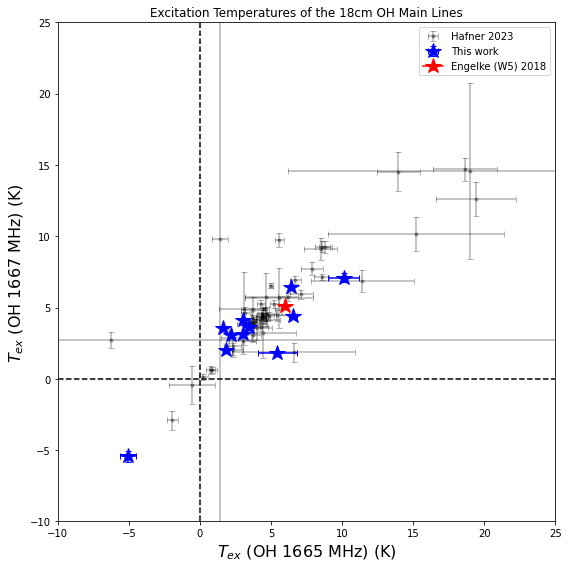

In [13]:
# Plot the data:
fig, axs = plt.subplots(1, figsize=(8, 8))

# Plot the OH:
axs.errorbar(x=Tex_hafner['1665'], y=Tex_hafner['1667'], xerr=Tex_hafner['+_1'], yerr=Tex_hafner['+_2'], marker='.', ls='', alpha=0.3, capsize=3, color='k', label='Hafner 2023')
axs.errorbar(x=results[results.Line == 1665]['Tex'], y=results[results.Line == 1667]['Tex'], xerr=results[results.Line == 1665]['\sigma Tex'], yerr=results[results.Line == 1667]['\sigma Tex'], marker='*', markersize=16, color='blue', ls='', capsize=3, label='This work')
axs.axvline(0, color='k', ls='dashed')
axs.axhline(0, color='k', ls='dashed')
axs.errorbar(x=6, y=5.1, yerr=0.2, xerr=0.5, marker='*', color='red', markersize=16, label='Engelke (W5) 2018')
axs.set_ylabel(r'$T_{ex}$ (OH 1667 MHz) (K)', size=16)
axs.set_xlabel(r'$T_{ex}$ (OH 1665 MHz) (K)', size=16)
axs.set_ylim([-10, 25])
axs.set_xlim([-10, 25])
axs.legend()
axs.set_title('Excitation Temperatures of the 18cm OH Main Lines')

fig.tight_layout()
#fig.savefig("Tex_firstDraft.pdf", format='pdf', dpi=400)
#fig.savefig("Tex_firstDraft.png", format='png', dpi=400)
#fig.savefig("Tex_IRonly_main.pdf", format='pdf', dpi=400)
#fig.savefig("Tex_IRonly_main.png", format='png', dpi=400)

# Plot the data:
#fig, axs = plt.subplots(1, figsize=(8, 8))

# Plot the OH:
#axs.errorbar(1/Tex_hafner['1612'], 1/Tex_hafner['1720'], marker='.', ls='', alpha=0.5, color='k', label='Hafner 2023')
#axs.errorbar(x=1/results[results.Line == 1612]['Tex'], y=1/results[results.Line == 1720]['Tex'], marker='*', markersize=16, color='blue', ls='', capsize=3, label='This work')
#axs.axvline(0, color='k', ls='dashed')
#axs.axhline(0, color='k', ls='dashed')
#axs.errorbar(x=6, y=5.1, yerr=0.2, xerr=0.5, marker='*', color='red', markersize=16, label='Engelke (W5) 2018')
#axs.set_ylabel(r'$1/T_{ex}$ (OH 1720 MHz) (K)', size=16)
#axs.set_xlabel(r'$1/T_{ex}$ (OH 1612 MHz) (K)', size=16)
#axs.set_ylim([-2, 2])
#axs.set_xlim([-2, 2])
#axs.legend()
#axs.set_title('Excitation Temperatures of the 18cm OH Satellite Lines')

#fig.tight_layout()
#fig.savefig("Tex_firstDraft.pdf", format='pdf', dpi=400)
#fig.savefig("Tex_firstDraft.png", format='png', dpi=400)
#fig.savefig("Tex_IRonly_satellite.pdf", format='pdf', dpi=400)
#fig.savefig("Tex_IRonly_satellite.png", format='png', dpi=400)

In [808]:
results = pd.concat([resultsTableW51, resultsTableW49, resultsTableG10, resultsTableG29, resultsTableW3, resultsTableG34, resultsTableG32], axis=0)

In [817]:
#results.to_csv('BuschResultsV2.csv')

In [8]:
results = pd.read_csv('BuschResults.csv')

In [9]:
results

,Unnamed: 0,Source,Component,Line,Peak,\sigma Peak,Center,\sigma Center,FWHM,\sigma FWHM,W,\sigma W,N(OH),Tex,\sigma Tex
0,1,W51,0,1667,-0.016374,0.004273,6.186371,0.129529,3.621850,0.320293,-0.063128,0.001457,5.065230e+13,3.610668,0.083324
1,2,W51,0,1665,-0.009420,0.003561,6.186371,0.129529,3.621850,0.320293,-0.036316,0.001214,5.065230e+13,3.486891,0.116587
2,3,W51,0,1612,-0.021628,0.003854,6.186371,0.129529,3.621850,0.320293,-0.083382,0.001314,5.065230e+13,0.303736,0.004787
3,4,W51,0,1720,0.023600,0.004050,6.186371,0.129529,3.621850,0.320293,0.090985,0.001381,5.065230e+13,-0.278355,0.004224
4,5,W51,0,316,-0.388252,0.055125,6.186371,0.129529,3.621850,0.320293,-1.496844,0.018794,5.065230e+13,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,10,G34,1,1612,-0.008141,0.003529,27.456919,0.127744,2.607037,0.264767,-0.022591,0.000995,6.044669e+13,1.337831,0.058907
73,11,G34,1,1720,-0.003049,0.003509,27.456919,0.127744,2.607037,0.264767,-0.008462,0.000989,6.044669e+13,3.571742,0.417395
74,12,G34,1,316,-0.534646,0.058247,27.456919,0.127744,2.607037,0.264767,-1.483700,0.016416,6.044669e+13,NaN,NaN
75,13,G34,1,298,-0.037960,0.004136,29.526919,0.127744,2.607037,0.264767,-0.105343,0.001166,6.830465e+13,NaN,NaN


NameError: name 'Tex_hafner' is not defined

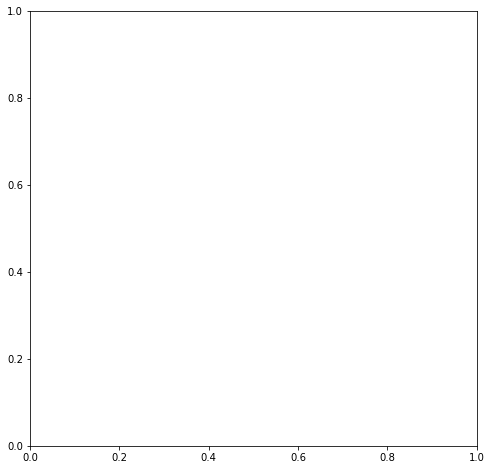

In [10]:
# Plot the data:
fig, axs = plt.subplots(1, figsize=(8, 8))

# Plot the OH:
axs.errorbar(Tex_hafner['1665'], Tex_hafner['1667'], marker='.', ls='', alpha=0.5, color='k', label='Hafner 2023')
axs.errorbar(x=results[results.Line == 1665]['Tex'], y=results[results.Line == 1667]['Tex'], marker='*', markersize=10, color='blue', ls='', capsize=3, label='This work')
axs.axvline(0, color='k', ls='dashed')
axs.axhline(0, color='k', ls='dashed')
#axs.errorbar(x=6, y=5.1, yerr=0.2, xerr=0.5, marker='*', color='red', markersize=16, label='Engelke (W5) 2018')
axs.set_ylabel(r'$1/T_{ex}$ (OH 1667 MHz) (K)', size=16)
axs.set_xlabel(r'$1/T_{ex}$ (OH 1665 MHz) (K)', size=16)
#axs.set_ylim([-1, 1])
#axs.set_xlim([-1, 1])
axs.legend()
axs.set_title('Excitation Temperatures of the 18cm OH Main Lines')

fig.tight_layout()
#fig.savefig("Tex_firstDraft.pdf", format='pdf', dpi=400)
#fig.savefig("Tex_firstDraft.png", format='png', dpi=400)
#fig.savefig("Tex_IRonly_main.pdf", format='pdf', dpi=400)
#fig.savefig("Tex_IRonly_main.png", format='png', dpi=400)


In [814]:
len(results[results.Line == '1665']['Tex'])

14

In [899]:
results = pd.concat([resultsTableW51, resultsTableG29, resultsTableG34], axis=0)

In [909]:
#results.to_csv('resultsBusch.csv')